In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 12.7 MB/s eta 0:00:00


In [2]:
# -----------------------------------------------------------------------------
# 0. IMPORTACIÓ DE LLIBRERIES (GLOBAL)
# -----------------------------------------------------------------------------

# Llibreries Estàndard de Python
import os
import time
import random
import zipfile

# Llibreries de Ciència de Dades i Matemàtiques
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Llibreries de Machine Learning Clàssic (Scikit-Learn)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score

# Llibreries de Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping

# Llibreries específiques de l'entorn (Google Colab)
from google.colab import drive

# Llibreries de Machine Learning i Mètriques
from sklearn.model_selection import LeaveOneGroupOut, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, recall_score
import seaborn as sns # Per fer gràfics macos (Heatmaps)

# Llibreries de Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Si no tens seaborn instal·lat, potser has de fer !pip install seaborn en una cel·la a part,
# però a Colab sol venir de sèrie.

# -----------------------------------------------------------------------------
# BLOC 0: EINES GLOBALS I CONFIGURACIÓ INICIAL
# -----------------------------------------------------------------------------
# Objectiu: Preparar l'entorn de treball amb totes les llibreries necessàries
# i definir funcions auxiliars que utilitzarem repetidament (DRY: Don't Repeat Yourself).
# -----------------------------------------------------------------------------

# 1. IMPORTACIÓ DE LLIBRERIES CIENTÍFIQUES I DE VISUALITZACIÓ
# -----------------------------------------------------------
import numpy as np          # El rei de les matemàtiques. Ens permet treballar amb matrius i vectors.
import time                 # Per cronometrar quant triga cada model (important per comparar eficiència).
import pandas as pd         # Per crear taules de resultats maques (DataFrames) al final.
import matplotlib.pyplot as plt # La llibreria base per fer gràfics (els eixos, els títols...).
import seaborn as sns       # Una capa per sobre de Matplotlib que fa els gràfics (com la Heatmap) més bonics.
import tensorflow as tf     # El cervell de Deep Learning (Google). Ens permet crear les xarxes neuronals.

# 2. IMPORTACIÓ D'EINES DE MACHINE LEARNING CLÀSSIC (Scikit-Learn)
# ----------------------------------------------------------------
# LeaveOneGroupOut: La clau del TFM. Ens permet fer la validació creuada deixant un subjecte fora.
# GroupShuffleSplit: Per fer subdivisions dins del Train (Train vs Validació) sense barrejar pacients.
from sklearn.model_selection import LeaveOneGroupOut, GroupShuffleSplit

# Mètriques per posar nota als models:
# accuracy_score: Nota global (% d'encerts).
# confusion_matrix: Ens diu on s'ha equivocat (ex: "Ha confós Seure amb Aixecar-se").
# classification_report: Ens dona la precisió i el recall per a cada classe individualment.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# StandardScaler: Per normalitzar les dades (que tinguin mitjana 0 i desviació 1).
# Vital perquè les xarxes neuronals no s'emboliquin amb números grans.
from sklearn.preprocessing import StandardScaler

# RandomForestClassifier: El nostre model "rival" (Baseline) per comparar si el Deep Learning val la pena.
from sklearn.ensemble import RandomForestClassifier

# compute_class_weight: La màgia per arreglar el desbalanceig. Calcula quant val cada error.
from sklearn.utils import compute_class_weight

# 3. IMPORTACIÓ DE COMPONENTS DE DEEP LEARNING (Keras)
# ----------------------------------------------------
# layers: Les peces de lego per muntar la xarxa (Conv1D, LSTM, Dense...).
# models: Per definir que el model és seqüencial (una capa darrere l'altra).
# optimizers: L'algorisme que ajusta els pesos (Adam és el millor per defecte).
from tensorflow.keras import layers, models, optimizers

# Callbacks: Són els "vigilants" de l'entrenament.
# EarlyStopping: Si el model deixa de millorar, l'atura per no perdre temps.
# ReduceLROnPlateau: Si el model s'encalla, redueix la velocitat d'aprenentatge per afinar més.
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# 1. Preparació de l'entorn

In [3]:
def fixar_reproductibilitat(seed=42):
    """
    Funció crítica per al TFM.
    Congela tots els generadors de nombres aleatoris per assegurar
    que els experiments siguin repetibles exactament igual.
    """
    print(f"🔒 Fixant la llavor global (Seed) a {seed} per a reproductibilitat...")

    # 1. Python natiu (random)
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)

    # 2. NumPy (Càlculs matemàtics i Data Augmentation)
    # Això farà que el 'Jittering' o 'Scaling' sempre apliquin el mateix soroll
    # en el mateix ordre.
    np.random.seed(seed)

    # 3. TensorFlow / Keras (Pesos inicials de la CNN/LSTM)
    # Això assegura que la xarxa comenci sempre amb les mateixes neurones.
    tf.random.set_seed(seed)

    # Opcional: Forçar TensorFlow a usar operacions deterministes (una mica més lent però segur)
    tf.config.experimental.enable_op_determinism()

    print("✅ Reproductibilitat configurada. Els resultats seran estables.")

# EXECUCIÓ OBLIGATÒRIA ABANS DE RES
fixar_reproductibilitat(42)

🔒 Fixant la llavor global (Seed) a 42 per a reproductibilitat...
✅ Reproductibilitat configurada. Els resultats seran estables.


In [4]:
def preparar_entorn():
    """
    Funció: preparar_entorn
    -----------------------
    Aquesta funció és el "Logístic" del projecte. Abans de tocar cap dada,
    s'assegura que els materials estan on toca.

    PROBLEMA QUE RESOL:
    Quan pugem un .zip a Google Colab, a vegades al descomprimir es crea una
    estructura imprevisible (ex: /content/DATA/DATA/s01...).
    Aquesta funció busca les dades siguin on siguin.

    Retorna:
        - ruta_base (str): L'adreça exacta de la carpeta on comencen els subjectes ('s01', etc.).
        - None: Si hi ha hagut un error crític (no troba el zip o està buit).
    """

    # Missatge de control per saber que el codi ha començat a rodar.
    print("--- 1. INICIANT PREPARACIÓ DE L'ENTORN ---")

    # -------------------------------------------------------------------------
    # 1. DEFINICIÓ DE RUTES (ON BUSQUEM I ON GUARDEM)
    # -------------------------------------------------------------------------
    # 'zip_path': On esperem trobar l'arxiu que has pujat manualment.
    zip_path = '/content/DATA.zip'

    # 'extract_path': On volem abocar el contingut.
    # Creem una carpeta pròpia 'DADES_TFM' per tenir-ho tot ordenat i no barrejar-ho
    # amb fitxers de sistema de Colab.
    extract_path = '/content/DADES_TFM'

    # -------------------------------------------------------------------------
    # 2. FASE DE DESCOMPRESSIÓ (EXTRACCIÓ)
    # -------------------------------------------------------------------------
    # PAS DE SEGURETAT: Abans de provar d'obrir res, preguntem al Sistema Operatiu:
    # "Existeix realment aquest fitxer aquí?". Això evita que el programa "peti" (Crash).
    if os.path.exists(zip_path):

        print("✅ Arxiu 'DATA.zip' localitzat correctament.")

        # DESCOMPRESSIÓ SEGURA (Context Manager 'with'):
        # La instrucció 'with' és com un contracte de lloguer:
        # 1. Obre el fitxer zip.
        # 2. Et deixa treballar a dins (el bloc indentat).
        # 3. Quan acabes (o si hi ha un error), TANCA el fitxer automàticament.
        # Això evita deixar arxius "zombis" oberts a la memòria.
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:

            # .extractall(): Agafa tot el contingut del zip i el tira a la carpeta destí.
            # EXEMPLE VISUAL:
            # Dins del ZIP: [s01, s02, subjects.csv]
            # Després d'això: /content/DADES_TFM/ ara conté [s01, s02, subjects.csv]
            zip_ref.extractall(extract_path)

        print("✅ Descompressió completada amb èxit.")

    else:
        # GESTIÓ D'ERRORS: Si l'arxiu no hi és, avisem a l'humà (tu) clarament.
        print("❌ ERROR CRÍTIC: No trobo l'arxiu 'DATA.zip'.")
        print("Acció requerida: Puja l'arxiu al panell de l'esquerra del Colab.")

        # Retornem 'None' per indicar a la resta del programa que s'aturi.
        return None

    # -------------------------------------------------------------------------
    # 3. FASE DE CERCA INTEL·LIGENT
    # -------------------------------------------------------------------------
    # A vegades, al descomprimir, es crea una subcarpeta extra.
    # Exemple: /content/DADES_TFM/DATASET_FINAL/s01...
    # Si busquem 's01' directament a l'arrel, fallaríem.

    ruta_base = None # Inicialitzem buit.

    # os.walk() és un explorador recursiu.
    # Comença a l'arrel i entra a TOTS els subdirectoris, un per un.
    # A cada pas ens dóna:
    #   - root: On soc ara.
    #   - dirs: Quines carpetes veig aquí.
    #   - files: Quins fitxers veig aquí.
    for root, dirs, files in os.walk(extract_path):

        # EL DETECTOR: Busquem la carpeta clau 's01' (el primer subjecte).
        # Si trobem 's01', sabem que estem al lloc correcte.
        # (Afegim 'S01' en majúscula per si de cas Windows ho ha canviat).
        if 's01' in dirs or 'S01' in dirs:

            # EUREKA! Hem trobat on s'amaguen les dades reals.
            # Guardem la ruta actual ('root') com a la nostra base d'operacions.
            ruta_base = root

            # STOP: Ja hem trobat el que volíem.
            # Trenquem el bucle (break) per no perdre temps mirant altres carpetes inútils.
            break

    # -------------------------------------------------------------------------
    # 4. VALIDACIÓ FINAL I RETORN
    # -------------------------------------------------------------------------
    if ruta_base:
        # ÈXIT: Hem trobat la carpeta i tenim la ruta.
        print(f"📍 Ruta Base detectada i configurada: {ruta_base}")

        # Retornem la ruta. A partir d'ara, la resta de funcions faran servir
        # aquesta variable per saber on anar a buscar els Excels.
        return ruta_base
    else:
        # FRACÀS: Hem mirat tot el disc i no hem vist 's01'.
        # Això vol dir que el ZIP estava corrupte o no tenia les dades esperades.
        print("❌ ERROR D'ESTRUCTURA: He descomprimit el zip però no trobo la carpeta 's01' a dins.")
        return None

# -----------------------------------------------------------------------------
# EXECUCIÓ PRINCIPAL
# -----------------------------------------------------------------------------
# Cridem la funció i guardem el resultat a la variable global BASE_PATH.
# Si tot va bé, BASE_PATH serà alguna cosa com: '/content/DADES_TFM/DATA'
BASE_PATH = preparar_entorn()

--- 1. INICIANT PREPARACIÓ DE L'ENTORN ---
✅ Arxiu 'DATA.zip' localitzat correctament.
✅ Descompressió completada amb èxit.
📍 Ruta Base detectada i configurada: /content/DADES_TFM/DATA


# 2. Fusió de Sensors i Sincronització Temporal (*Sensor Fusion*)



In [5]:
import pandas as pd
import os

# -----------------------------------------------------------------------------
# FUNCIÓ 1: FUSIÓ INDIVIDUAL (NIVELL MICRO)
# -----------------------------------------------------------------------------
def carregar_una_execucio(execution_id, base_path):
    """
    Funció: carregar_una_execucio
    -----------------------------
    Aquesta és la funció "obrera". S'encarrega de la feina bruta de processar
    UN sol cas (una parella de fitxers Mòbil + Rellotge).

    Paràmetres:
        - execution_id: L'identificador únic (ex: 's01_01').
        - base_path: La ruta arrel que hem trobat al pas anterior.

    Retorna:
        - df_combined: El DataFrame (taula) fusionat i net.
        - None: Si no troba els fitxers (gestió d'errors).
    """

    # -------------------------------------------------------------------------
    # PAS 1: CONSTRUCCIÓ DE RUTES (Path Building)
    # -------------------------------------------------------------------------
    # Necessitem saber a quina carpeta buscar.
    # Fem servir .split('_')[0] per agafar "s01" de l'string "s01_01".
    subject_id = execution_id.split('_')[0]

    # Gestió de robustesa (Majúscules/Minúscules):
    # A vegades les carpetes es diuen "S01" i a vegades "s01".
    # Aquest bloc assegura que trobem la carpeta sigui com sigui.
    # EXEMPLE: Si base_path='/data' i subject_id='s01' -> '/data/S01' o '/data/s01'

    path_subject = os.path.join(base_path, subject_id.upper()) # Provem S01
    if not os.path.exists(path_subject):
        path_subject = os.path.join(base_path, subject_id.lower()) # Provem s01

    # Construïm els noms complets dels fitxers específics.
    # f-strings ens permeten injectar l'ID dins del nom del fitxer dinàmicament.
    # EXEMPLE DE RESULTAT (file_sp): "/content/DADES_TFM/s01/s01_01_sp.csv"
    file_sp = os.path.join(path_subject, f"{execution_id}_sp.csv") # sp = SmartPhone
    file_sw = os.path.join(path_subject, f"{execution_id}_sw.csv") # sw = SmartWatch

    # -------------------------------------------------------------------------
    # PAS 2: LECTURA DE DADES (I/O Operations)
    # -------------------------------------------------------------------------
    try:
        # Intentem llegir els CSVs i carregar-los a la memòria RAM com a DataFrames.
        # Pandas converteix el text del CSV en una taula manipulable.
        df_phone = pd.read_csv(file_sp)
        df_watch = pd.read_csv(file_sw)
    except FileNotFoundError:
        # Si un fitxer no existeix, no petem el programa.
        # Avisem i retornem "Res" (None) perquè el bucle principal ho sàpiga i continuï.
        print(f"❌ ALERTA: No s'han trobat fitxers per a l'ID {execution_id}")
        return None

    # -------------------------------------------------------------------------
    # PAS 3: DESAMBIGUACIÓ DE NOMS (Feature Renaming)
    # -------------------------------------------------------------------------
    # PROBLEMA: Tots dos DataFrames tenen columnes que es diuen igual (ex: 'x_acc').
    # Si les ajuntem ara, tindríem dues columnes 'x_acc' i no sabríem quina és quina.
    #
    # SOLUCIÓ: Afegim prefixos per saber de qui és cada dada.
    #
    # EXEMPLE DE TRANSFORMACIÓ:
    #   Abans (Mòbil):   ['x_acc', 'y_acc', 'z_acc', ...]
    #   Després (Mòbil): ['phone_x_acc', 'phone_y_acc', 'phone_z_acc', ...]

    # List Comprehension: Recorrem totes les columnes i els posem "phone_" davant.
    df_phone.columns = [f"phone_{col}" for col in df_phone.columns]

    # El mateix per al rellotge, amb el prefix "watch_".
    #   Abans (Rellotge): ['x_acc', ...]
    #   Després (Rellotge): ['watch_x_acc', ...]
    df_watch.columns = [f"watch_{col}" for col in df_watch.columns]

    # -------------------------------------------------------------------------
    # PAS 4: SINCRONITZACIÓ (Truncation Strategy)
    # -------------------------------------------------------------------------
    # PROBLEMA: Els sensors mai s'aturen al mil·lisegon exacte.
    # Exemple: El mòbil té 1000 files i el rellotge en té 1005.
    # Pandas no pot ajuntar taules de diferent llargada sense crear buits (NaNs).
    #
    # SOLUCIÓ: Tallem el sobrant del més llarg ("Minimum Length Truncation").

    len_p = len(df_phone)
    len_w = len(df_watch)

    # Calculem quin és el més curt (el límit bo).
    # EXEMPLE: min(1000, 1005) -> 1000
    min_len = min(len_p, len_w)

    # Apliquem el tall.
    # .iloc[:min_len] vol dir: "Queda't des de la fila 0 fins a la fila min_len".
    # Les files sobrants (del 1000 al 1005) s'eliminen.
    df_phone = df_phone.iloc[:min_len]
    df_watch = df_watch.iloc[:min_len]

    # -------------------------------------------------------------------------
    # PAS 5: FUSIÓ FINAL (Concatenation)
    # -------------------------------------------------------------------------
    # Ara que tenen la mateixa alçada (ex: 1000 files), els enganxem de costat.
    # axis=1 indica que volem sumar columnes (horitzontal), no files (vertical).
    #
    # RESULTAT VISUAL:
    #   Taula Final (df_combined):
    #   [ Fila 0: Dades Mòbil  |  Dades Rellotge ]
    #   [ Fila 1: Dades Mòbil  |  Dades Rellotge ]
    #   ...

    df_combined = pd.concat([df_phone, df_watch], axis=1)

    return df_combined

In [6]:
def carregar_dataset_complet(base_path):
    """
    Funció: carregar_dataset_complet
    --------------------------------
    Aquesta funció actua com a "Director d'Orquestra".
    Llegeix la llista de totes les proves (executions_info.csv) i utilitza
    la funció anterior ('carregar_una_execucio') per processar-les una per una.
    """
    print("\n--- 2. INICIANT FUSIÓ MASSIVA DE SENSORS ---")

    # -------------------------------------------------------------------------
    # PAS 1: LOCALITZAR I LLEGIR L'INVENTARI
    # -------------------------------------------------------------------------
    # Construïm la ruta al fitxer que té la llista de tot el que hem de carregar.
    # EXEMPLE: base_path + "executions_info.csv" -> ".../DATA/executions_info.csv"
    csv_index = os.path.join(base_path, 'executions_info.csv')

    if os.path.exists(csv_index):
        # Carreguem l'índex a la memòria.
        # EXEMPLE VISUAL DEL QUE CONTÉ 'df_index':
        # -----------------------------------------
        # |   | execution_id | orientation | ...  |
        # |---|--------------|-------------|------|
        # | 0 | s01_01       | back_inv    | ...  |
        # | 1 | s01_02       | back_inv    | ...  |
        # | 2 | s01_03       | front       | ...  |
        # ... (fins a 223 files)
        df_index = pd.read_csv(csv_index)
        total_execucions = len(df_index)
        print(f"📋 S'han detectat {total_execucions} execucions per processar al CSV.")
    else:
        print("❌ ERROR CRÍTIC: No trobo 'executions_info.csv'.")
        return None

    # -------------------------------------------------------------------------
    # PAS 2: PREPARAR EL MAGATZEM (DICCIONARI)
    # -------------------------------------------------------------------------
    # Inicialitzem el diccionari buit. Aquí anirem guardant les taules.
    # Al principi està buit: {}
    dataset_dict = {}
    comptador = 0

    # -------------------------------------------------------------------------
    # PAS 3: EL BUCLE PRINCIPAL (ITERACIÓ)
    # -------------------------------------------------------------------------
    # df_index['execution_id'] és una llista: ['s01_01', 's01_02', 's01_03'...]
    # El bucle agafa un element d'aquesta llista a cada volta.

    # EXEMPLE DE FUNCIONAMENT DEL BUCLE:
    # Volta 1: exec_id val 's01_01'
    # Volta 2: exec_id val 's01_02'
    # Volta 3: exec_id val 's01_03'
    # ... així fins al final.

    for exec_id in df_index['execution_id']:

        # A. CRIDA A L'OBRER
        # Li diem a la funció de fusió: "Ves a buscar els fitxers de 's01_01' i ajunta'ls".
        # Això ens retorna una taula (DataFrame) amb les dades d'aquell moment.
        df_resultat = carregar_una_execucio(exec_id, base_path)

        # B. EMMAGATZEMATGE
        # Si l'obrer ha trobat els fitxers (no és None), els guardem al magatzem.
        if df_resultat is not None:

            # Guardem la taula dins del diccionari amb la seva etiqueta.
            # El diccionari conté els dataframes ja units.
            # EXEMPLE DE COM CREIX EL DICCIONARI:
            # Volta 1: { 's01_01': [Taula de 1350 files] }
            # Volta 2: { 's01_01': [...], 's01_02': [Taula de 1200 files] }
            dataset_dict[exec_id] = df_resultat

            comptador += 1

        # Barra de progrés visual (imprimim un punt cada 20 arxius).
        if comptador % 20 == 0:
            print(".", end="")

    # -------------------------------------------------------------------------
    # PAS 4: RESUM FINAL
    # -------------------------------------------------------------------------
    print(f"\n✅ PROCÉS COMPLETAT: S'han carregat correctament {comptador} de {total_execucions} fitxers.")

    # Retornem el diccionari ple amb les 223 taules a dins.
    return dataset_dict

# -----------------------------------------------------------------------------
# EXECUCIÓ DEL BLOC
# -----------------------------------------------------------------------------
# Cridem a la funció principal i guardem el resultat a la variable global 'dataset_dict'.
dataset_dict = carregar_dataset_complet(BASE_PATH)


--- 2. INICIANT FUSIÓ MASSIVA DE SENSORS ---
📋 S'han detectat 223 execucions per processar al CSV.
...........
✅ PROCÉS COMPLETAT: S'han carregat correctament 223 de 223 fitxers.


# 3.  Validació de Consistència



In [7]:
import pandas as pd

# -----------------------------------------------------------------------------
# DEFINICIÓ DEL MAPA D'ETIQUETES (CONSTANTS)
# -----------------------------------------------------------------------------
# Aquest diccionari actua com a "traductor universal".
LABEL_MAPPING = {
    'SEATED': 0,
    'STANDING_UP': 1,
    'WALKING': 2,
    'TURNING': 3,
    'SITTING_DOWN': 4
}

def processar_etiquetes(dataset_dict):
    """
    Funció: processar_etiquetes
    Aplica la lògica de negoci per netejar i codificar les etiquetes.

    Operacions principals:
    1. Resolució de conflictes (Master-Slave).
    2. Traducció de Text a Números.
    3. Eliminació de columnes sobrants.
    """
    print("\n 3. INICIANT CODIFICACIÓ I VALIDACIÓ D'ETIQUETES ")

    total_conflictes = 0
    arxius_amb_conflictes = 0

    # Iterem per cada arxiu del nostre dataset
    for key, df in dataset_dict.items():

        # PAS 1: DETECCIÓ DE CONFLICTES (AUDITORIA)

        # Comparem la columna del mòbil amb la del rellotge fila a fila.
        # Exemple visual:
        #    Mòbil      Rellotge     Resultat Comparació
        #    "WALKING"  "WALKING" -> False (No hi ha conflicte)
        #    "WALKING"  "SEATED"  -> True  (ALERTA! Conflicte)

        mask_conflict = df['phone_label'] != df['watch_label']
        num_conflictes = mask_conflict.sum()

        if num_conflictes > 0:
            total_conflictes += num_conflictes
            arxius_amb_conflictes += 1

        # ---------------------------------------------------------------------
        # PAS 2: APLICACIÓ DE L'ESTRATÈGIA MASTER-SLAVE
        # ---------------------------------------------------------------------
        # Decisió: El Mòbil (Master) sempre té la raó.
        # Creem una nova columna 'activity' copiant les dades del mòbil.
        #
        # Exemple d'aplicació:
        #    Cas Conflictiu: Mòbil="WALKING", Rellotge="SEATED"
        #    Acció: Ignorem "SEATED".
        #    Resultat a df['activity']: "WALKING"
        # Creem la columna activity

        df['activity'] = df['phone_label']


        # PAS 3: TRADUCCIÓ (MAPPING)


        # Utilitzem .map() per convertir les paraules en números usant el diccionari.
        #
        # Exemple de transformació real:
        #    Entrada (df['activity']): ['SEATED', 'SEATED', 'WALKING']
        #    Operació: .map(LABEL_MAPPING)
        #    Sortida (df['activity_id']): [0, 0, 2]
        # Creem la columna activity_id fent map de la columna activity.

        df['activity_id'] = df['activity'].map(LABEL_MAPPING)

        # CONTROL D'ERRORS:
        # Si al CSV hi hagués una activitat "JUMPING" (que no està al diccionari),
        # el resultat seria NaN (Not a Number). Hem de vigilar-ho.
        if df['activity_id'].isnull().any():
            etiquetes_rares = df[df['activity_id'].isnull()]['activity'].unique()
            print(f"❌ ERROR CRÍTIC a {key}: Etiqueta desconeguda: {etiquetes_rares}")
            return None

        # ---------------------------------------------------------------------
        # PAS 4: NETEJA FINAL (DROP COLUMNS)
        # ---------------------------------------------------------------------
        # Un cop tenim l'ID numèric (2), ja no necessitem el text ("WALKING").
        # Eliminem les columnes velles per deixar la taula neta.
        #
        # Exemple:
        #    Columnes Abans: ['phone_acc_x', ..., 'phone_label', 'activity_id']
        #    Acció: drop(['phone_label', ...])
        #    Columnes Després: ['phone_acc_x', ..., 'activity_id']

        cols_a_eliminar = ['phone_label', 'watch_label', 'activity']
        df.drop(columns=cols_a_eliminar, inplace=True)

    # -------------------------------------------------------------------------
    # RESUM FINAL
    # -------------------------------------------------------------------------
    print(f"📊 Resum de l'Auditoria:")
    print(f"   - Arxius processats: {len(dataset_dict)}")
    print(f"   - Arxius amb discrepàncies menors: {arxius_amb_conflictes}")
    print(f"   - Total mostres corregides (Master-Slave): {total_conflictes}")
    print("✅ Etiquetatge completat. Totes les columnes són ara numèriques.")

    return dataset_dict

# -----------------------------------------------------------------------------
# EXECUCIÓ DEL BLOC
# -----------------------------------------------------------------------------
dataset_dict = processar_etiquetes(dataset_dict)



 3. INICIANT CODIFICACIÓ I VALIDACIÓ D'ETIQUETES 
📊 Resum de l'Auditoria:
   - Arxius processats: 223
   - Arxius amb discrepàncies menors: 223
   - Total mostres corregides (Master-Slave): 15116
✅ Etiquetatge completat. Totes les columnes són ara numèriques.


In [8]:
# VERIFICACIÓ VISUAL RÀPIDA
# Ensenyem les primeres 3 files per demostrar que ara tenim números
primer_cas = list(dataset_dict.keys())[0]
print(f"\n🔍 Mostra del resultat ({primer_cas}):")
# Això et donarà una llista: ['phone_x_acc', 'phone_y_acc', ..., 'activity_id']
print(list(dataset_dict[primer_cas].columns))


🔍 Mostra del resultat (s01_01):
['phone_x_acc', 'phone_y_acc', 'phone_z_acc', 'phone_x_gyro', 'phone_y_gyro', 'phone_z_gyro', 'phone_timestamp', 'watch_x_acc', 'watch_y_acc', 'watch_z_acc', 'watch_x_gyro', 'watch_y_gyro', 'watch_z_gyro', 'watch_timestamp', 'activity_id']


# 4. Auditoria Empírica de la Freqüència de Mostreig ($F_s$)





In [9]:
def auditar_frequencia(dataset_dict):
    """
    Funció: auditar_frequencia
    --------------------------
    Analitza els timestamps abans de ser eliminats per determinar matemàticament
    la velocitat real del sensor (Freqüència de Mostreig).

    Retorna:
        - WINDOW_SIZE (int): La mida de finestra òptima (128 o 256).
    """
    print("\n--- 4. AUDITORIA DE FREQÜÈNCIA (REAL VS TEÒRICA) ---")

    # -------------------------------------------------------------------------
    # PAS 1: SELECCIÓ DE LA MOSTRA (EL CONILLET D'ÍNDIES)
    # -------------------------------------------------------------------------

    # Volem agafar la primera clau del diccionari.
    # EXEMPLE VISUAL DEL DICCIONARI 'dataset_dict':
    # {
    #    's01_01': <DataFrame Object>,  <-- Volem aquesta etiqueta
    #    's01_02': <DataFrame Object>,
    #    ...
    # }

    # list(dataset_dict.keys()) converteix les etiquetes en una llista:
    # -> ['s01_01', 's01_02', 's01_03', ...]
    # [0] agafa la primera de totes.
    clau_exemple = list(dataset_dict.keys())[0]

    # Resultat: clau_exemple = 's01_01'
    print(f"🔍 Analitzant fitxer mostra: {clau_exemple}")

    # Ara recuperem la taula (DataFrame) que hi ha guardada sota aquesta clau.

    df = dataset_dict[clau_exemple]

    # -------------------------------------------------------------------------
    # PAS 2: ANÀLISI DEL MÒBIL (CÀLCUL DE DELTAS)
    # -------------------------------------------------------------------------

    # Comprovem si tenim la columna del temps.
    if 'phone_timestamp' in df.columns:

        # EXTRAIEM ELS VALORS A UN ARRAY DE NUMPY (VECTOR)
        # EXEMPLE DE DADES REALS (Unix Timestamp en mil·lisegons):
        # temps_ms = [ 1657533977810,  <-- Mostra 0
        #              1657533977819,  <-- Mostra 1
        #              1657533977828,  <-- Mostra 2
        #              1657533977838 ] <-- Mostra 3
        temps_ms = df['phone_timestamp'].values

        # CALCULEM LA DIFERÈNCIA ENTRE VEÏNS (DELTA)
        # np.diff fa: (Mostra 1 - Mostra 0), (Mostra 2 - Mostra 1)...
        #
        # CÀLCUL REAL:
        #   1657533977819 - 1657533977810 = 9 ms
        #   1657533977828 - 1657533977819 = 9 ms
        #   1657533977838 - 1657533977828 = 10 ms
        #
        # RESULTAT (deltas): [9, 9, 10, ...]
        deltas = np.diff(temps_ms)

        # CALCULEM LA MITJANA
        mitjana_delta_ms = np.mean(deltas)

        # TRANSFORMACIÓ A HERTZ (FREQÜÈNCIA)
        freq_real = 1000 / mitjana_delta_ms

        print(f"📊 Resultats Mòbil:")
        print(f"   - Interval mitjà entre mostres: {mitjana_delta_ms:.2f} ms")
        print(f"   - Freqüència Calculada: {freq_real:.2f} Hz")

    else:
        # Gestió d'errors per si executem el codi dues vegades i ja hem esborrat la columna.
        print("⚠️ Error: No trobo 'phone_timestamp'. Ja l'has esborrat?")
        return 128 # Tornem el valor per defecte per no trencar el codi.

    # -------------------------------------------------------------------------
    # PAS 3: Decidim la freqüència
    # -------------------------------------------------------------------------
    # Aquí decidim quina mida de finestra necessitem basant-nos en la realitat.

    # ESCENARI A: La freqüència és alta (Més de 90 Hz).
    # Si F = 100 Hz, en 2.56 segons entren 256 mostres.
    if freq_real > 90:
        print("El sistema treballa a Alta Freqüència (~100Hz).")
        print("Ajustem la finestra a 256 mostres per mantenir 2.56s de durada i capturar una acció completa")
        return 256

    # ESCENARI B: La freqüència és estàndard (Menys de 90 Hz).
    # Si F = 50 Hz, en 2.56 segons entren 128 mostres.
    else:
        print(" El sistema treballa a Freqüència Estàndard (~50Hz).")
        print("Ajustem la finestra a 128 mostres per mantenir 2.56s de durada HO DIU ORDOÑEZ?????? i capturar una acció completa")
        return 128

# -----------------------------------------------------------------------------
# EXECUCIÓ DEL BLOC
# -----------------------------------------------------------------------------
# Guardem el resultat (256 o 128) en una variable global per utilitzar-la a la Part 5.
WINDOW_SIZE_OPTIMA = auditar_frequencia(dataset_dict)


--- 4. AUDITORIA DE FREQÜÈNCIA (REAL VS TEÒRICA) ---
🔍 Analitzant fitxer mostra: s01_01
📊 Resultats Mòbil:
   - Interval mitjà entre mostres: 9.76 ms
   - Freqüència Calculada: 102.47 Hz
El sistema treballa a Alta Freqüència (~100Hz).
Ajustem la finestra a 256 mostres per mantenir 2.56s de durada i capturar una acció completa


# 5. Neteja Final i Segmentació Temporal (*Windowing*)




In [10]:
# -----------------------------------------------------------------------------
# CONFIGURACIÓ D'HIPERPARÀMETRES (LA GEOMETRIA DE LES DADES)
# -----------------------------------------------------------------------------
# Decisió presa a l'Auditoria (Part 4):
# Freqüència real = 100 Hz.
# Càlcul: 100 mostres/segon * 2.56 segons = 256 mostres.

WINDOW_SIZE = 256  # L'amplada de la "foto" que veu la IA.
OVERLAP = 0.5      # Volem que les fotos se solapin un 50% per no perdre detalls a les vores.

# Càlcul del pas (Step): Cada quant movem la càmera?
# Si la finestra és 256 i el solapament és 50% (0.5), hem d'avançar la meitat.
# 256 * (1 - 0.5) = 128.
STEP = int(WINDOW_SIZE * (1 - OVERLAP))

def generar_dataset_final(dataset_dict):
    """
    Funció: generar_dataset_final
    -----------------------------
    1. Agafa els fulls de càlcul (2D).
    2. Els retalla en fitxes petites (Windows).
    3. Els apila en un bloc sòlid (Tensor 3D).

    Retorna 3 objectes sincronitzats:
        - X: Les dades (El vídeo). Forma: (N_Finestres, 256, 12).
        - y: Les respostes (L'etiqueta). Forma: (N_Finestres).
        - groups: Els autors (El subjecte). Forma: (N_Finestres).
    """
    print(f"5. GENERANT DATASET FINAL (Finestra={WINDOW_SIZE}, Step={STEP})")

    # PAS 1: NETEJA DE TIMESTAMPS PREVENTIVA (SANITITZACIÓ)

    # Per què? El 'timestamp' és un número que creix infinitament (1657...).
    # Si el deixem, el model es pensarà que "com més gran és el número, més cansat està l'usuari".
    # Això és fals (biaix). L'eliminem per obligar el model a mirar només el moviment.

    cols_brossa = ['phone_timestamp', 'watch_timestamp']

    # Iterem per totes les taules del diccionari i esborrem aquestes columnes.
    for k in dataset_dict:
        # fem drop(..., errors='ignore'), si no hi són cap problema, seguim.
        dataset_dict[k].drop(columns=cols_brossa, inplace=True, errors='ignore')

    # PAS 2: PREPARACIÓ DELS CONTENIDORS

    # Creem llistes buides. Aquí anirem tirant les "fitxes" que retallem.
    segments = []  # Aquí aniran les matrius de 256x12 (Dades).
    labels = []    # Aquí anirà el número de l'activitat (0, 1, 2...).
    groups = []    # Aquí anirà l'ID del subjecte (1, 2, ... 23).


    # PAS 3: BUCLE MESTRE (PROCESSAMENT ARXIU PER ARXIU)

    # key: El nom de l'arxiu (ex: 's01_01').
    # df: La taula de dades que hi ha a dins.
    for key, df in dataset_dict.items():

        # A. EXTRACCIÓ DE L'ID DEL SUBJECTE
        # ---------------------------------
        # Necessitem saber de qui és aquest arxiu per poder fer LOSO després.
        # Lògica: 's01_01' -> split('_') -> 's01' -> treure 's' -> '01' -> int -> 1.
        subject_part = key.split('_')[0] # 's01'
        subject_id = int(subject_part.replace('s', '').replace('S', '')) # Eliminem la lletra

        # B. SEPARACIÓ DE SENSORS I ETIQUETES
        # -----------------------------------
        # La taula té 13 columnes (12 sensors + 1 activitat).
        # Les separem perquè les tractarem diferent.

        #Fem una llista amb tots els noms de les columnes de la taula menys la columna activity_id.
        col_sensors = [c for c in df.columns if c != 'activity_id']

        # Agafa la taula gran, selecciona NOMÉS les columnes que tenim a la llista
        # col_sensors (les 12 primeres) i converteix-ho en una matriu de números
        # dades: Matriu de (N_files, 12). (es com tot l'excel en una llista
        # de llistes.)
        dades = df[col_sensors].values
        # etiquetes: Vector de (N_files).
        # és una llista (1D) amb totes les etiquetes és a dir: [0,1,2,3,1,2..]
        etiquetes = df['activity_id'].values

       # ---------------------------------------------------------------------
        # C. BUCLE DE SEGMENTACIÓ (SLIDING WINDOW)
        # ---------------------------------------------------------------------
        # Aquest bucle és el cor de la transformació 2D -> 3D.
        #
        # DECISIÓ CRÍTICA DE DISSENY: 'Drop Remainder' (Descartar Residu)
        # ---------------------------------------------------------------
        # Fixem-nos en el límit del range: "len(df) - WINDOW_SIZE".
        #
        # Per què parem abans del final?
        # Les Xarxes Neuronals (CNN) són estructures rígides. Esperen rebre
        # blocs d'entrada de dimensions exactes (ex: 256x12).
        #
        # Si l'arxiu té 1000 mostres i la finestra és de 256:
        #   - Podem fer 3 finestres completes (3 * 256 = 768).
        #   - Sobren 232 mostres al final.
        #
        # OPCIONS:
        #   A) Zero-Padding: Omplir el final amb zeros fins a 256. (Introdueix soroll/dades falses).
        #   B) Drop Remainder: Llençar les 232 mostres finals. (Mantenim qualitat màxima).
        #
        # Hem triat l'opció B. Sacrifiquem el final de la gravació (sovint sorollós per aturar l'app)
        # per garantir que TOTS els tensors tinguin dades reals i completes.

        for i in range(0, len(df) - WINDOW_SIZE, STEP):

            # 1. RETALLAR LA FINESTRA DE DADES ("LA FOTO")
            # --------------------------------------------
            # Agafem un "tall" exacte de 256 mostres (2.56 segons reals a 100Hz).
            # Això garanteix capturar almenys 2 cicles complets de caminar (1.2s cadascun).
            finestra = dades[i : i + WINDOW_SIZE]

            # 2. RETALLAR LA FINESTRA D'ETIQUETES ("EL GUIÓ")
            # -----------------------------------------------
            # Agafem les etiquetes corresponents a aquests 2.56 segons.
            # Exemple real de transició:
            # [2, 2, 2, ..., 0, 0] (L'usuari estava caminant i s'ha assegut al final).
            finestra_labels = etiquetes[i : i + WINDOW_SIZE]

            # 3. CONSOLIDACIÓ DE L'ETIQUETA (CRITERI DE LA MODA)
            # --------------------------------------------------
            # La Xarxa Neuronal necessita UNA sola resposta per finestra (Classificació).
            # No li podem dir "és un 80% caminar i un 20% seure".
            #
            # Solució: "Majority Voting" (Votació democràtica).
            # Calculem la Moda estadística.
            #   - Si hi ha 200 mostres de 'WALKING' (2)
            #   - I hi ha 56 mostres de 'SEATED' (0)
            #   - Resultat: La finestra es cataloga com 'WALKING' (2).
            #
            # Això permet capturar l'activitat predominant i no perdre transicions.

            # Utilitzem stats.mode que retorna una llista amb la moda i el nombre
            # vegades que ha sortit.
            moda_result = stats.mode(finestra_labels, keepdims=True)
            etiqueta = moda_result.mode[0] #Agafem la moda

           # -----------------------------------------------------------------
            # 4. EMMAGATZEMATGE (AMPLIACIÓ DE LES LLISTES)
            # -----------------------------------------------------------------
            # En aquest punt, les variables són llistes de Python dinàmiques.
            # Van creixent a mesura que trobem finestres noves.

            # A. SEGMENTS (Les Dades)
            # És una LLISTA DE MATRIUS (List of Arrays).
            # Cada element que hi afegim és una 'finestra' (un array NumPy de 256x12).
            #
            # Visualització de la llista 'segments':
            # [
            #   Matriu_Finestra_0 (256x12),
            #   Matriu_Finestra_1 (256x12),
            #   Matriu_Finestra_2 (256x12),
            #   ...
            # ]
            segments.append(finestra)

            # B. LABELS (Les Respostes)
            # És una LLISTA DE NÚMEROS (1D).
            # Cada element és un enter que diu què passava en aquella finestra.
            #
            # Visualització de la llista 'labels':
            # [ 2, 2, 2, 0, 0, 1, ... ]  (Caminar, Caminar, Seure...)
            labels.append(etiqueta)

            # C. GROUPS (La Traçabilitat)
            # Què és? Una LLISTA DE NÚMEROS (1D).
            # Cada element és l'ID del subjecte propietari d'aquella finestra.
            # Això és vital per saber, al final, quines finestres són del Subjecte 1.
            #
            # Visualització de la llista 'groups':
            # [ 1, 1, 1, ..., 2, 2, ... ]
            groups.append(subject_id)

   # -------------------------------------------------------------------------
    # PAS 4: CONVERSIÓ FINAL A TENSORS (LA SOLIDIFICACIÓ)
    # -------------------------------------------------------------------------

   # ACCIÓ 1: CREAR L'ESTRUCTURA DE DADES FINAL (X)
    # np.array() transforma la llista en una estructura de 3 nivells (Tensor).
    #
    # Com imaginar-ho: Un llibre de 1.683 pàgines. (1683 ho sabem perk ja ho hem executat)
    # - Nivell 1 (1683): El número de pàgina (cada pàgina és una finestra).
    # - Nivell 2 (256):  Les línies de la pàgina (el temps).
    # - Nivell 3 (12):   Les columnes de la pàgina (els sensors)

    # Tenim 1.683 matrius independents (finestres), on cadascuna conté 256 files
    # (instants de temps) i 12 columnes (valors dels sensors)..

    X = np.array(segments)

    # ACCIÓ 2: CREAR EL VECTOR D'ETIQUETES (y)
    # 'labels' era una llista: [0, 0, 2, 2, 1...]
    # np.array() ho converteix en un vector rígid.
    # Forma: (1683,) -> Una línia de 1683 números.
    y = np.array(labels)

    # ACCIÓ 3: CREAR EL VECTOR DE SUBJECTES (groups)
    # Igual que abans. Necessitem saber de qui és cada finestra.
    # Forma: (1683,) -> Una línia amb [1, 1, ... 5, 5 ...].
    groups = np.array(groups)

    print("\n🎉 PROCÉS COMPLETAT! Dataset llest per a Deep Learning.")

    # -------------------------------------------------------------------------
    # VERIFICACIÓ DE LES DIMENSIONS (EXEMPLE DE LECTURA)
    # -------------------------------------------------------------------------
    # Aquest print és vital per saber si hem fet bé el trencaclosques.

    # X.shape retorna una tupla (ex: 1683, 256, 12)
    print(f"X (Input - Sensors):   {X.shape}")

    print(f"🏷️ y (Target - Classes):  {y.shape}")

    print(f"👤 groups (Subjectes):    {groups.shape}")

    return X, y, groups

# -----------------------------------------------------------------------------
# EXECUCIÓ FINAL
# -----------------------------------------------------------------------------
# Executem la funció. Aquestes variables (X, y, groups) són les que
# passarem directament als models (Random Forest i CNN).
X, y, groups = generar_dataset_final(dataset_dict)


5. GENERANT DATASET FINAL (Finestra=256, Step=128)

🎉 PROCÉS COMPLETAT! Dataset llest per a Deep Learning.
X (Input - Sensors):   (1683, 256, 12)
🏷️ y (Target - Classes):  (1683,)
👤 groups (Subjectes):    (1683,)


## Resum i Verificació de l'Estructura de Dades


Tenim **1.683 clips de moviment** de 2.56 segons cadascun, perfectament etiquetats i identificats per usuari, a punt per entrar al model.

# 6. Establiment del Baseline: Machine Learning Clàssic


In [11]:
# FUNCIÓ 1: FEATURE ENGINEERING (L'APLANADORA)

def extreure_features_estadistiques(X_tensor):
    """
    Funció: extreure_features_estadistiques
    ---------------------------------------
    Transforma el Tensor 3D (Temporal) en una Taula 2D (Estadística) apta per a ML clàssic.

    EXEMPLE CONCEPTUAL (Per a un sol sensor):?
        - ENTRADA (Una finestra de 256 mostres):
          [0.1, 0.2, 0.8, 0.9, ..., 0.1]

        - PROCÉS (Càlcul d'estadístics):
          1. Mitjana: 0.45  (Centre de gravetat)
          2. Desviació: 0.30 (Intensitat del moviment)
          3. Màxim: 0.90 (Pic d'impacte)
          4. Mínim: 0.10 (Vall)

        - SORTIDA (1 fila de 4 columnes):
          [0.45, 0.30, 0.90, 0.10]

    INPUT:
       X_tensor: (1683 finestres, 256 mostres_temps, 12 sensors)

    OUTPUT:
       X_features: (1683 finestres, 48 característiques) -> (12 sensors * 4 estadístics)
    """
    print("--- INICIANT FEATURE ENGINEERING (3D -> 2D) ---")
    print(f"   1. Dimensions d'entrada (Raw): {X_tensor.shape}")

    # -------------------------------------------------------------------------
    # CÀLCUL D'ESTADÍSTICS (Col·lapse de l'eix temporal axis=1)
    # -------------------------------------------------------------------------
    # axis=1 significa: "Per a cada finestra i cada sensor, aixafa les 256 mostres temporalment".

    # 1. MITJANA: Ens diu "on" està el sensor (inclinació/gravetat).
    # Exemple: Si Acc_X oscil·la voltant de 9.8, el mòbil està vertical.
    # "np.mean converteix cada finestra de 256 files x 12 columnes en 1 fila x 12 columnes."
    # Agafa els 256 valors de cada columna i fa la mitjana.
    mean = np.mean(X_tensor, axis=1)  # Resultat: Matriu de (1683, 12)

    # A continuació fem el mateix per buscar les altres tres magnituds

    # 2. DESVIACIÓ ESTÀNDARD: Ens diu "quant" es mou.
    # Exemple: Si std és alt, l'usuari està corrent. Si és baix, està assegut.
    std = np.std(X_tensor, axis=1)    # Resultat: Matriu de (1683, 12)

    # 3. MÀXIM: Ens diu el pic més fort (impacte del peu al terra).
    max_v = np.max(X_tensor, axis=1)  # Resultat: Matriu de (1683, 12)

    # 4. MÍNIM: Ens diu el valor més baix.
    min_v = np.min(X_tensor, axis=1)  # Resultat: Matriu de (1683, 12)

    # -------------------------------------------------------------------------
    # CONCATENACIÓ (AJUNTAR PECES)
    # -------------------------------------------------------------------------
    # Ara tenim 4 matrius separades de (1683, 12). Les volem juntes.
    # np.hstack posa les matrius una al costat de l'altra horitzontalment.
    #
    # RESULTAT VISUAL:
    # [ Mitjana (12 cols) | Std (12 cols) | Max (12 cols) | Min (12 cols) ]
    # Total = 48 columnes.

    # Tenim una matriu de 1683 files i 48 columnes.
    # Que serà l'entrada del nostre random forest.
    X_features = np.hstack([mean, std, max_v, min_v])

    print(f"Dimensions de sortida (Features): {X_features.shape}")
    return X_features

# -----------------------------------------------------------------------------
# FUNCIÓ 2: EL MODEL I LA VALIDACIÓ (LOSO)
# -----------------------------------------------------------------------------

#Una manera de fer l'entrenament seria agafar totes les finestres i fer 80% train i 20% test
#Però cada persona fa les accions a la seva manera. Si el model ha vist com camina el subjecte 1
# a l'entrenament, quan el vegi a test el reconeixerà i tindrem un 99% d'accuracy
# però si posem el model a classificar altres persones, fallarà estrepitosament perk no
# reconeixerà a ningú.

#LOSO soluciona això. El model no veu res del subjecte amb el qual es fa el test.
# P.ex: Train: (2-23), Test(1)

def avaluar_baseline_rf(X, y, groups):
    """
    Entrena i avalua un Random Forest utilitzant Leave-One-Subject-Out.
    """
    print("\n--- 6. INICIANT VALIDACIÓ LOSO AMB RANDOM FOREST ---")

    # 1. PREPARACIÓ DE DADES
    # Convertim el tensor 3D en la taula 2D que necessita el Random Forest.
    X_2d = extreure_features_estadistiques(X)

    # 2. CONFIGURACIÓ DEL VALIDADOR
    # LeaveOneGroupOut és un objecte intel·ligent de Sklearn.
    # Quan li passem el vector 'groups' (els subjectes), ell sap com dividir.
    # Creem el generador d'indexs loso.
    loso = LeaveOneGroupOut()

    # Llistes buides per anar guardant les notes obtingudes.
    acc_scores = []
    f1_scores = []

    # 3. DEFINICIÓ DEL MODEL (L'ALGORISME)
    # JUSTIFICACIÓ: Oshiro et al. (2012) demostren que el rendiment s'estabilitza
    # entre 64 i 128 arbres. Augmentar-lo més no millora significativament l'accuracy
    # i penalitza el temps de còmput. 100 és l'estàndard d'eficiència.
    #
    # random_state=42: Reproductibilitat (fixem l'atzar).
    # n_jobs=-1: Paral·lelisme (tots els nuclis de la CPU
    # Random Forest: Un conjunt de 100 arbres de decisió que voten.
    # n_jobs=-1: Utilitza tots els nuclis del processador per anar ràpid.
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

    #1. INICI DEL CRONÒMETRE
    # La funció time.time() captura l'hora actual exacta (en segons des de 1970).
    # Guardem aquest instant a 'start_time'.
    # PER QUÈ? Al final de tot, farem (Ara - start_time) per saber quants segons
    # ha trigat l'ordinador a fer tots els càlculs. És una mètrica d'eficiència.
    start_time = time.time()

    # 2. INICIALITZACIÓ DEL COMPTADOR VISUAL
    # Creem una variable 'fold' (plec/volta) i la posem a 1.
    # Simplement per imprimir per pantalla "Estem a la volta 1", "Volta 2"...
    fold = 1

    # 3. CÀLCUL DEL TOTAL D'ITERACIONS PREVISTES
    # Preguntem a l'objecte 'loso': "Quantes divisions faràs amb aquestes dades?".
    # - Input: Li passem les dades (X, y) i sobretot els GRUPS (subjectes).
    # - Procés: Ell compta quants IDs únics hi ha a 'groups' (hi ha 23 persones).
    # - Output: Ens retorna el número 23.
    # Per poder imprimir "Volta 1 de 23". Sense això no sabríem quan acaba.
    total_folds = loso.get_n_splits(X_2d, y, groups)

    print(f"\nIniciant bucle de {total_folds} iteracions...")

    # 4. BUCLE PRINCIPAL (ITERACIÓ PER SUBJECTE)
    # Aquest bucle s'executa 23 vegades.
    # train_idx: Llista de files per estudiar (22 subjectes).
    # test_idx: Llista de files per examinar-se (1 subjecte).
    for train_idx, test_idx in loso.split(X_2d, y, groups):
      #Exemple train_idx = [80,81,...,1682]
      #        test_idx = [0,1,2...,79] (Subjecte 1, p.ex)

      # Que són les files on estan els subjectes.
      # Recordem que X_2d es una matriu de 1683 files i 48 columnes

        # A. SEPARACIÓ (SPLITTING)

        # Anem a la taula X_2d. Agafa només les files que tinc apuntades a la
        # llista train_idx (la 80, la 81...) i fes-me una taula nova només amb això
        X_train, X_test = X_2d[train_idx], X_2d[test_idx]

        #Idem per el conjunt y.
        #Anem al vector on estan les etiquetes i les guardem.
        y_train, y_test = y[train_idx], y[test_idx]

        # Mirem quin subjecte és el que fem servir de test.
        # Com que totes les files de test tenen el mateix subjecte, mirem la primera.
        subjecte_actual = groups[test_idx][0]

        # B. ENTRENAMENT (FIT)
        # El model busca patrons matemàtics (llindars) en les dades d'entrenament.
        # Exemple: "Si Mitjana_Acc > 0.5 --> Aleshores és Caminar".
        rf_model.fit(X_train, y_train)

        # C. PREDICCIÓ (PREDICT)
        # El model intenta endevinar l'activitat del subjecte nou basant-se en el que ha après.
        y_pred = rf_model.predict(X_test)

        # D. AVALUACIÓ (METRICS)
        # Comparem el que ha dit el model (y_pred) amb la realitat (y_test).
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted') # 'weighted' pondera per classes desbalancejades.

        # Guardem les notes a la llibreta
        acc_scores.append(acc)
        f1_scores.append(f1)

        # Imprimim el resultat d'aquesta volta
        print(f"   📝 Iteració {fold}/{total_folds} (Subjecte {subjecte_actual}): Accuracy = {acc:.2%} | F1 = {f1:.2f}")
        fold += 1

    elapsed = time.time() - start_time

    # -------------------------------------------------------------------------
    # RESULTATS FINALS (LA NOTA FINAL)
    # -------------------------------------------------------------------------
    mitjana_acc = np.mean(acc_scores)
    std_acc = np.std(acc_scores) # Desviació (estabilitat del model)

    print("\n" + "="*60)
    print(f"RESULTAT FINAL DEL BASELINE (RANDOM FOREST)")
    print("="*60)
    print(f"⏱️ Temps de càlcul: {elapsed:.2f} segons")
    print(f"📊 Accuracy Mitjana (Cross-User): {mitjana_acc:.2%} (+/- {std_acc:.2%})")
    print(f"📈 F1-Score Mitjà:                {np.mean(f1_scores):.4f}")
    print("="*60)

    return mitjana_acc

# EXECUCIÓ
# Passem les dades (X), etiquetes (y) i grups (groups) a la funció.
resultat_baseline = avaluar_baseline_rf(X, y, groups)



--- 6. INICIANT VALIDACIÓ LOSO AMB RANDOM FOREST ---
--- INICIANT FEATURE ENGINEERING (3D -> 2D) ---
   1. Dimensions d'entrada (Raw): (1683, 256, 12)
Dimensions de sortida (Features): (1683, 48)

Iniciant bucle de 23 iteracions...
   📝 Iteració 1/23 (Subjecte 1): Accuracy = 86.96% | F1 = 0.84
   📝 Iteració 2/23 (Subjecte 2): Accuracy = 83.56% | F1 = 0.82
   📝 Iteració 3/23 (Subjecte 3): Accuracy = 79.69% | F1 = 0.78
   📝 Iteració 4/23 (Subjecte 4): Accuracy = 88.73% | F1 = 0.86
   📝 Iteració 5/23 (Subjecte 5): Accuracy = 82.35% | F1 = 0.80
   📝 Iteració 6/23 (Subjecte 6): Accuracy = 60.44% | F1 = 0.51
   📝 Iteració 7/23 (Subjecte 7): Accuracy = 73.03% | F1 = 0.68
   📝 Iteració 8/23 (Subjecte 8): Accuracy = 80.52% | F1 = 0.79
   📝 Iteració 9/23 (Subjecte 9): Accuracy = 88.73% | F1 = 0.87
   📝 Iteració 10/23 (Subjecte 10): Accuracy = 72.60% | F1 = 0.73
   📝 Iteració 11/23 (Subjecte 11): Accuracy = 94.59% | F1 = 0.94
   📝 Iteració 12/23 (Subjecte 12): Accuracy = 79.49% | F1 = 0.77
   📝 

# 7. Arquitectura Deep Learning: Convolutional Neural Network (1D-CNN)



In [12]:
# -----------------------------------------------------------------------------
# FUNCIÓ AUXILIAR 1: DATA AUGMENTATION (El Gimnàs de Dades)
# -----------------------------------------------------------------------------
# OBJECTIU: Fer el model més robust.
# PROBLEMA: Tenim poques dades (Small Data). El model podria memoritzar-les exactament.
# SOLUCIÓ: Creem "còpies" de les dades afegint-hi una mica de soroll.
# És com si el sensor vibrés una mica més. Això obliga el model a aprendre el patró, no el valor exacte.

def augmentar_dades(X_train, y_train):
    """Afegeix soroll gaussià per evitar overfitting."""

    # 1. Fem una còpia de les dades originals per no espatllar-les
    X_aug = X_train.copy()

    # 2. Generem soroll aleatori
    # loc=0.0: Centrat en 0.
    # scale=0.05: La intensitat del soroll. Prou petit per no canviar l'activitat,
    # però prou gran per generar variabilitat.
    soroll = np.random.normal(loc=0.0, scale=0.05, size=X_train.shape)

    # 3. Sumem el soroll a les dades copiades
    X_aug = X_aug + soroll

    # 4. Retornem el conjunt DOBLE: Les dades netes + Les dades amb soroll.
    # Així tenim el doble d'exemples per entrenar!
    # np.concatenate enganxa les dues llistes.
    # Primer posem les dades originals (X_train) i a sota les dades amb soroll (X_aug).
    # Fem el mateix amb les etiquetes (y_train), repetint-les perquè són les mateixes per a tots dos grups.
    return np.concatenate((X_train, X_aug)), np.concatenate((y_train, y_train))

    #Si augmenteem les dades abans de separar Train/Test,
    #tindrem dades "clonades" (molt semblants) a l'entrenament i al test. Llavors el model tindrà un 99% d'encert,
    #però serà mentida. Només s'ha de fer Augmentation al conjunt de TRAIN.

# -----------------------------------------------------------------------------
# FUNCIÓ 2: INFORME VISUAL
# -----------------------------------------------------------------------------
# En lloc de donar només un número (80%), ensenyem ON falla el model amb gràfics.

def mostrar_informe_tutor(y_real, y_pred, titol_model):
    print(f"\n📊 --- RESULTATS: {titol_model} ---")

    # 1. Matriu de Confusió Visual
    # Definim els noms per no veure només números (0,1,2...) al gràfic
    noms_activitats = ['SEATED', 'STANDING_UP', 'WALKING', 'TURNING', 'SITTING_DOWN']

    # Calculem la matriu (Comparació Realitat vs Predicció)
    cm = confusion_matrix(y_real, y_pred)

    # Dibuixem el mapa de calor (Heatmap)
    plt.figure(figsize=(8, 6))
    # cmap='Blues': Utilitza colors blaus (més fosc = més encerts)
    # annot=True: Escriu el número dins de cada quadre
    # fmt='d': Format decimal (sense decimals estranys)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=noms_activitats, yticklabels=noms_activitats)

    plt.title(f'Matriu de Confusió: {titol_model}')
    plt.ylabel('Realitat')   # Eix Y: Què feia l'usuari realment
    plt.xlabel('Predicció')  # Eix X: Què ha dit el model
    plt.show()

    # 2. Informe detallat (Text)
    # Mostrem Precision, Recall i F1-Score per a cada activitat.
    # Això és vital per veure si fallem en les classes petites (com Turning).
    print("\n--- DETALL PER CLASSE (RECALL/SENSIBILITAT) ---")
    print(classification_report(y_real, y_pred, target_names=noms_activitats))

#1. Experiment Base: CNN Standard
En aquest bloc implementem el nostre primer candidat de Deep Learning: una Xarxa Neuronal Convolucional (CNN). L'objectiu és veure fins on podem arribar utilitzant només la capacitat de la xarxa per detectar patrons "espacials" (pics, valls, formes d'ona) en les dades dels sensors, sense tenir encara una memòria temporal explícita (com les LSTM).

Aquesta arquitectura ens servirà de punt de partida (Baseline) per comparar després si afegir complexitat (LSTM) realment val la pena.


--- 🚀 FASE 1: CNN STANDARD ---
CNN | Suj 1: 76.09%
CNN | Suj 2: 87.67%


CNN | Suj 3: 67.19%


CNN | Suj 4: 78.87%
CNN | Suj 5: 82.35%
CNN | Suj 6: 62.64%
CNN | Suj 7: 71.91%
CNN | Suj 8: 79.22%
CNN | Suj 9: 90.14%
CNN | Suj 10: 58.90%
CNN | Suj 11: 94.59%
CNN | Suj 12: 66.67%
CNN | Suj 13: 82.81%
CNN | Suj 14: 76.47%
CNN | Suj 15: 90.16%
CNN | Suj 16: 80.26%
CNN | Suj 17: 77.11%
CNN | Suj 18: 69.41%
CNN | Suj 19: 82.19%
CNN | Suj 20: 68.92%
CNN | Suj 21: 59.26%
CNN | Suj 22: 61.29%
CNN | Suj 23: 78.12%

✅ FINAL CNN: 75.75%

📊 --- RESULTATS: CNN Standard ---


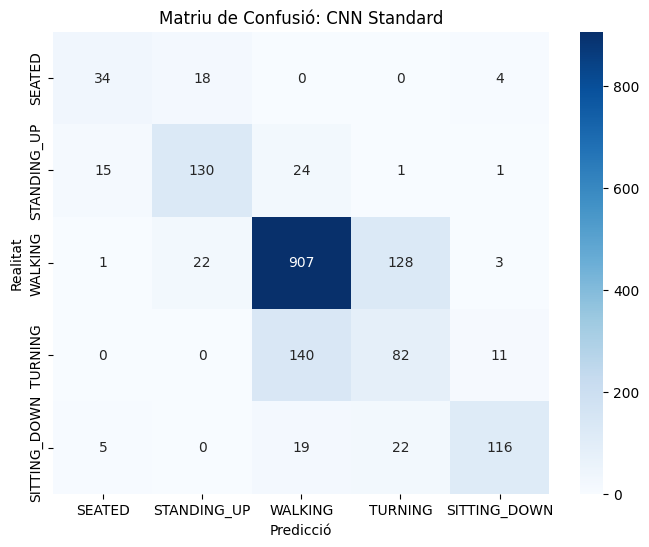


--- DETALL PER CLASSE (RECALL/SENSIBILITAT) ---
              precision    recall  f1-score   support

      SEATED       0.62      0.61      0.61        56
 STANDING_UP       0.76      0.76      0.76       171
     WALKING       0.83      0.85      0.84      1061
     TURNING       0.35      0.35      0.35       233
SITTING_DOWN       0.86      0.72      0.78       162

    accuracy                           0.75      1683
   macro avg       0.69      0.66      0.67      1683
weighted avg       0.75      0.75      0.75      1683



In [13]:
# =============================================================================
# BLOC 1: EXPERIMENT AMB CNN STANDARD
# =============================================================================
# Objectiu: Avaluar el rendiment d'una xarxa convolucional pura.
# Hipòtesi: La CNN hauria de ser capaç de detectar patrons com "passos" o "cops",
# però potser li costa entendre seqüències llargues (com girar-se durant 3 segons).

# -----------------------------------------------------------------------------
# 1. DISSENY DE L'ARQUITECTURA (El plànol de la casa)
# -----------------------------------------------------------------------------
def crear_model_cnn(input_shape, num_classes):
    """
    Construeix una CNN d'1 Dimensió (perquè el temps és 1D, no una foto 2D).
    Estructura: 3 blocs de convolució -> Resum Global -> Classificació.
    """

    # 1.1. INICI DEL MODEL SEQÜENCIAL
    # Imaginem el model com una canonada: les dades entren per un costat
    # i passen capa per capa fins a sortir per l'altre.
    model = models.Sequential()

    # 1.2. LA PORTA D'ENTRADA (Input Layer)
    # Li diem al model quina forma tenen les dades que rebrà.
    # input_shape = (256, 12) -> Finestres de 256 mostres de temps x 12 sensors.
    # Sense això, el model no sabria quantes neurones posar a la primera capa.
    model.add(layers.Input(shape=input_shape))

    # BLOC 1: DETECCIÓ DE DETALLS FINS (Micro-patrons)
    # Aquest bloc s'encarregarà de veure coses molt petites (ex: un pic brusc d'acceleració).

    # Conv1D (Convolució): L'escàner.
    # - filters=64: Posem 64 "llanternes" diferents a mirar les dades. Cada una aprendrà a buscar una cosa (una pujada, una baixada...).
    # - kernel_size=3: Cada llanterna il·lumina 3 mostres de cop. És una visió molt "zoom in".
    # - activation='relu': La funció que encén la neurona. Si detecta alguna cosa positiva, deixa passar el senyal. Si és negatiu, posa 0.
    # - padding='same': Truc important! Afegeix zeros a les vores perquè la sortida tingui la mateixa llargada que l'entrada (no perdem dades als extrems).
    model.add(layers.Conv1D(64, 3, activation='relu', padding='same'))

    # - Surt: (256 temps x 64 mapes d'activació).
    #   JA NO SÓN SENSORS. Ara són "nivells d'alerta" de cada filtre.
    #   Si la llantera busca un 'cop sec', el seu mapa tindrà números alts on hi hagi cops.
    #   activation='relu': Si el detectiu diu "aquí no hi ha res" (número negatiu),
    #   Si diu "aquí hi ha molt!" (número 50), ho deixa en 50.

    # BatchNormalization: S'assegura que els números que surten de la capa anterior estiguin equilibrats (ni molt grans ni molt petits).
    # Això fa que el model aprengui molt més ràpid i sigui més estable.
    # A mesura que les dades viatgen per les capes, les operacions matemàtiques
    # poden descontrolar els valors (fer-los gegants o diminuts).
    # BatchNormalization torna a centrar les dades (mitjana 0, var 1) ENTRE CAPA I CAPA.
    # Això permet que la xarxa aprengui molt més ràpid i sense encallar-se.

    model.add(layers.BatchNormalization())

    # MaxPooling1D:
    # pool_size=2: Agafa les dades de 2 en 2 i es queda només amb el valor MÀXIM.
    # Ex: [0.1, 0.9] -> [0.9].
    # Efecte: Redueix la mida de les dades a la meitat (de 256 a 128) i es queda només amb els "pics" importants.
    model.add(layers.MaxPooling1D(2))

    # Dropout:
    # 0.2 (20%): Apaga aleatòriament el 20% de les neurones a cada passada.
    # Realment El dropout agafa la quadrícula anterior de 8.192 números i en selecciona el 20% a l'atzar (uns 1.638 números) i els hi posa un 0.
    # Les altres es queden igual.
    # Per què? Per obligar a la xarxa a no dependre d'una sola neurona. Evita que "copiïn" a l'examen (Overfitting).
    model.add(layers.Dropout(0.2))

    # --- BLOC 2: PATRONS INTERMEDIS (Combinació de detalls) ---
    # Ara que tenim dades més resumides (128 de llarg), busquem patrons més complexos.
    # Ex: "Un pic seguit d'una vall" (un pas complet).

    # Augmentem els filtres a 128: Com que les dades són més petites, ens podem permetre tenir més "llanternes" mirant.
    model.add(layers.Conv1D(128, 3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization()) # Re-equilibrem.
    model.add(layers.MaxPooling1D(2))      # Tornem a reduir a la meitat (de 128 a 64).
    model.add(layers.Dropout(0.3))         # Pugem el dropout (30%) perquè ara tenim més neurones i més risc de memoritzar.

    # --- BLOC 3: PATRONS COMPLEXOS (Visió Global) ---
    # Ara mirem dades molt resumides (64 de llarg). Aquí busquem el "concepte" de l'activitat.

    # Encara més filtres (256) per capturar moltes combinacions possibles.
    model.add(layers.Conv1D(256, 3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())

    # GlobalAveragePooling1D:
    # En lloc de fer un altre MaxPooling, aquí fem la MITJANA de tot el que queda.
    # Teniem (64 temps x 256 característiques).
    # Per a cada columna, calcula la mitjana de tots els temps. Ara tenim un sol vector de 256 números
    # Ja no hi ha "temps", només "característiques".
    model.add(layers.GlobalAveragePooling1D())
    model.add(layers.Dropout(0.4)) # Dropout alt (40%) abans de la decisió final.

    # --- CAPA DE CLASSIFICACIÓ  ---

    # Dense (Fully Connected): Connectem totes les característiques amb 128 neurones finals per pensar la resposta.
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5)) # Dropout màxim (50%) per assegurar que el model està molt segur del que diu.

    # CAPA DE SORTIDA (La Resposta):
    # - Dense(num_classes): Tenim 5 activitats, per tant, 5 neurones de sortida.
    # - activation='softmax': Converteix els números en PROBABILITATS que sumen 100%.
    # Ex: [0.1, 0.8, 0.05, 0.05, 0.0] -> "Estic al 80% segur que és la classe 1".
    model.add(layers.Dense(num_classes, activation='softmax'))

    # COMPILACIÓ (Preparar el motor):
    # - optimizer='Adam': El millor algorisme per ajustar els pesos (learning rate 0.001 és estàndard).
    # - loss='sparse...': La forma de calcular l'error quan les etiquetes són números enters (0, 1, 2...).
    # - metrics=['accuracy']: Volem que ens digui quin % encerta.
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# -----------------------------------------------------------------------------
# 2. MOTOR D'ENTRENAMENT (El Bucle LOSO)
# -----------------------------------------------------------------------------
def executar_cnn(X, y, groups):
    print("\n--- 🚀 FASE 1: CNN STANDARD ---")

    # Inicialitzem llistes buides per guardar tot el que passi
    y_true = []      # La realitat (què feien els subjectes).
    y_pred = []      # La predicció (què ha dit el model).
    acc_scores = []  # Les notes de cada examen (un per subjecte).

    # CONFIGURACIÓ DE L'EXPERIMENT

    # 1. LeaveOneGroupOut: L'àrbitre que ens diu "Ara toca el Subjecte 1", "Ara el 2"...
    loso = LeaveOneGroupOut()

    # 2. GroupShuffleSplit: L'eina per fer la "validació interna" (el simulacre d'examen).
    # Dels 22 subjectes d'entrenament, en separarem un 15% (aprox 3 persones) per vigilar si el model memoritza.
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)

    # 3. Callbacks:
    # - EarlyStopping: "Si en 15 èpoques no millores la nota del simulacre, para i no perdis temps."
    # - restore_best_weights=True: "Quan paris, torna enrere i queda't amb la millor versió que tenies, no l'última."
    early_stop = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, mode='max')

    # - ReduceLROnPlateau: "Si veus que t'encalles (l'error no baixa en 5 èpoques), redueix la velocitat a la meitat (factor 0.5) per ser més precís."
    # # "Velocitat" aquí es refereix al LEARNING RATE (la mida del pas que fa la xarxa
    # quan corregeix els seus errors).
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-5)

    fold = 1 # Comptador per saber per quin subjecte anem (1/23...)

    # --- INICI DEL BUCLE PRINCIPAL (23 VOLTES) ---
    # Per cada volta, 'loso.split' ens dona els índexs per entrenar (22 pers) i per test (1 pers).
    for train_ix, test_ix in loso.split(X, y, groups):
    # train_ix: És una LLISTA DE NÚMEROS (Índexs). Diu quines files corresponen als 22 alumnes que "estudien".
    #           Ex: [0, 1, 2, 100, 101, ... 1682]
    # test_ix:  És una LLISTA DE NÚMEROS. Diu quines files corresponen a l'alumne que "s'examina".
    #           Ex: [50, 51, 52 ... 99] (Totes les files del Subjecte X).

    #Estem recorrent X (1.683, 256, 12). Aquí hi ha les 1683 finestres amb tots els subjectes.

        # A. SEPARACIÓ FÍSICA DE DADES
        # Agafem les dades segons els índexs que ens ha donat el LOSO.
        # X_train_full: Els 22 subjectes per estudiar.
        # X_test: El subjecte per a l'examen final.
        X_train_full, X_test = X[train_ix], X[test_ix]
        y_train_full, y_test = y[train_ix], y[test_ix]
        groups_train = groups[train_ix] # Necessitem saber qui és qui dins del train.

        # B. EL SIMULACRE (Validació Interna)
        # Dels 22 d'estudi, en traiem 3 a l'atzar per fer de validació.
        # t_ix: Índexs per entrenar de debò (19 pers).
        # v_ix: Índexs per validar (3 pers).
        t_ix, v_ix = next(splitter.split(X_train_full, y_train_full, groups_train))

        X_tr, X_val = X_train_full[t_ix], X_train_full[v_ix]
        y_tr, y_val = y_train_full[t_ix], y_train_full[v_ix]

        # C. NORMALITZACIÓ
        # IMPORTANT: El model ha d'aprendre l'escala (mitjana/desviació) NOMÉS del Train.
        # Mai pot veure el Test ni la Validació per calcular això (seria fer trampes).
        # Data leakage
        scaler = StandardScaler()

        # 1. Aplanem (Reshape) a 2D perquè el Scaler no entén 3D.
        # Tenim un dades (3D): [Finestres, Temps, Sensors].

        # El StandardScaler és una eina clàssica que només entén TAULES (2D): [Files, Columnes].
        # Si li donem el cub, peta.
        # Convertim el cub en una taula llarguíssima posant totes les finestres una sota l'altra
        X_tr_flat = X_tr.reshape(-1, 12)

        # 1.APRENENTATGE (FIT)
        # Dins del parèntesi NOMÉS hi ha 'X_tr' (Train).
        # El 'scaler' aprèn la mitjana i desviació NOMÉS dels alumnes de classe.
        # NO veu ni el 'X_val' ni el 'X_test'.
        scaler.fit(X_tr_flat)

        # 2. APLICACIÓ (TRANSFORM)
        # Aplica la fórmula matemàtica (Valor - Mitjana) / Desviació a totes les dades.
        # Utilitza la mitjana i desviació del Train que ha après al pas anterior.

        X_tr = scaler.transform(X_tr_flat).reshape(X_tr.shape)
        X_val = scaler.transform(X_val.reshape(-1, 12)).reshape(X_val.shape)
        X_test = scaler.transform(X_test.reshape(-1, 12)).reshape(X_test.shape)


        # D. DATA AUGMENTATION
        # Cridem la funció global que hem definit abans.
        # NOMÉS ho fem al conjunt d'entrenament (X_tr).
        # Ara X_tr té el doble de dades (originals + soroll).
        X_tr, y_tr = augmentar_dades(X_tr, y_tr)

        # E. CREACIÓ DEL MODEL
        # Netegem la memòria de la targeta gràfica per començar de zero.
        tf.keras.backend.clear_session()
        # Creem una xarxa nova sense res a dins.
        model = crear_model_cnn((256, 12), 5)

        # F. ENTRENAMENT (FIT)
        # Aquí és on el model aprèn.
        # - epochs=100: Li donem fins a 100 oportunitats per millorar.
        # - batch_size=32: Estudia en paquets petits (32 finestres) per fixar-se en els detalls.
        # - validation_data: Li passem l'examen de simulacre perquè l'EarlyStopping sàpiga quan parar.
        # - verbose=0: Que no ompli la pantalla de text mentre entrena (silenciós).
        model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                  epochs=100, batch_size=32, callbacks=[early_stop, reduce_lr], verbose=0)

        # G. EXAMEN FINAL (PREDICT)
        # El model ja entrenat fa l'examen sobre el subjecte que no havia vist mai (X_test).
        # model.predict torna probabilitats (ex: [0.1, 0.9, ...]).
        # np.argmax es queda amb la posició més alta (ex: 1 -> STANDING).
        pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

        # Guardem els resultats
        y_true.extend(y_test) # Guardem la realitat acumulada
        y_pred.extend(pred)   # Guardem la predicció acumulada

        # Calculem la nota d'aquest alumne concret
        acc_scores.append(accuracy_score(y_test, pred))

        # Imprimim el progrés
        # Ex: "CNN | Suj 1: 85.00%"
        print(f"CNN | Suj {groups[test_ix][0]}: {acc_scores[-1]:.2%}")
        fold += 1 # Agafa el valor que tens ara, suma-li 1, i guarda'l.

    # --- FINALITZACIÓ ---
    # Calculem la nota mitjana de tot el curs (els 23 subjectes).
    print(f"\n✅ FINAL CNN: {np.mean(acc_scores):.2%}")

    # Cridem la funció global per fer el gràfic bonic i l'informe detallat.
    mostrar_informe_tutor(y_true, y_pred, "CNN Standard")

    # Retornem les prediccions per si més tard les volem comparar.
    return y_pred

# EXECUCIÓ
# Llancem la funció i guardem el resultat.
y_pred_cnn = executar_cnn(X, y, groups)

#2. El Model Guanyador: DeepConvLSTM
En aquest bloc implementem l'arquitectura proposada per Ordóñez i Roggen (2016), que combina dues tecnologies clau:

CNN (Convolucions): Actuen com a "extractors de característiques", netejant el senyal i trobant patrons locals.

LSTM (Recurrència): Actuen com a "cervell temporal", entenent la seqüència i el context (ex: "si abans corria i ara frena, segurament es girarà").

A més, implementem una Estratègia de Pesos Manuals per combatre el desbalanceig del dataset. Com que WALKING domina, forcem al model a prestar més atenció a TURNING i SEATED mitjançant penalitzacions personalitzades.


--- 🚀 FASE 2: DEEPCONV-LSTM (PESOS MANUALS AGRESSIUS) ---
⚖️ Pesos aplicats: {0: 2.5, 1: 2.0, 2: 0.9, 3: 3.5, 4: 1.5}
LSTM | Suj 1: 86.96%
LSTM | Suj 2: 78.08%
LSTM | Suj 3: 76.56%
LSTM | Suj 4: 81.69%
LSTM | Suj 5: 89.71%
LSTM | Suj 6: 61.54%
LSTM | Suj 7: 73.03%
LSTM | Suj 8: 81.82%
LSTM | Suj 9: 91.55%
LSTM | Suj 10: 86.30%
LSTM | Suj 11: 82.43%
LSTM | Suj 12: 65.38%
LSTM | Suj 13: 82.81%
LSTM | Suj 14: 83.53%
LSTM | Suj 15: 85.25%
LSTM | Suj 16: 78.95%
LSTM | Suj 17: 78.31%
LSTM | Suj 18: 87.06%
LSTM | Suj 19: 84.93%
LSTM | Suj 20: 82.43%
LSTM | Suj 21: 80.25%
LSTM | Suj 22: 75.81%
LSTM | Suj 23: 84.38%

✅ FINAL LSTM (MANUAL): 80.82%

📊 --- RESULTATS: DeepConvLSTM (Pesos Manuals) ---


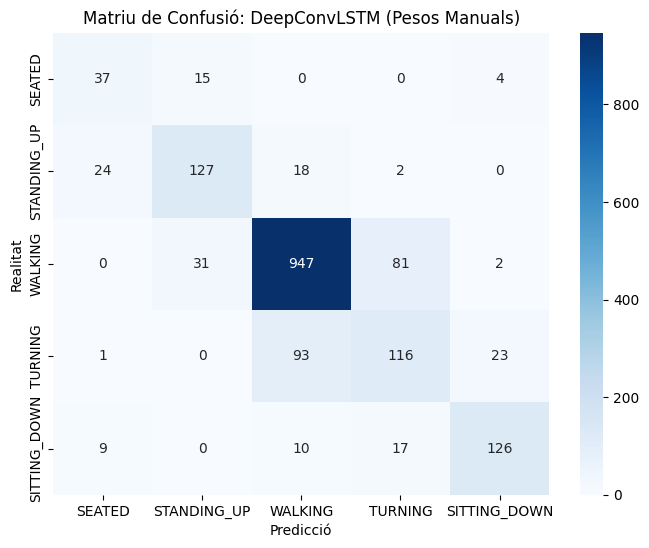


--- DETALL PER CLASSE (RECALL/SENSIBILITAT) ---
              precision    recall  f1-score   support

      SEATED       0.52      0.66      0.58        56
 STANDING_UP       0.73      0.74      0.74       171
     WALKING       0.89      0.89      0.89      1061
     TURNING       0.54      0.50      0.52       233
SITTING_DOWN       0.81      0.78      0.79       162

    accuracy                           0.80      1683
   macro avg       0.70      0.71      0.70      1683
weighted avg       0.80      0.80      0.80      1683



In [22]:
# =============================================================================
# BLOC 2: EXPERIMENT AMB DEEPCONV-LSTM (L'EVOLUCIÓ)
# =============================================================================
# Objectiu: Superar la CNN afegint memòria temporal.
# Eina clau: Capes LSTM (Long Short-Term Memory).

# -----------------------------------------------------------------------------
# 1. DISSENY DE L'ARQUITECTURA HÍBRIDA (CNN + LSTM)
# -----------------------------------------------------------------------------
def crear_model_lstm(input_shape, num_classes):
    """
    Construeix la xarxa definitiva.
    No és només una pila de capes, és un sistema de dues parts.
    """
    # 1. Iniciem l'estructura seqüencial (fila índia de capes).
    model = models.Sequential()

    # 2. L'ENTRADA
    # input_shape=(256, 12): Entren finestres de 2.56 segons amb 12 sensors.
    model.add(layers.Input(shape=input_shape))

    # --- PART 1: EL "FRONT-END" (Extracció de Features Visuals) ---
    # Aquesta part funciona igual que la CNN. "Mira" les dades i busca formes.

    # BLOC CNN 1 (Detalls Fins)
    # -------------------------
    # Conv1D (64 filtres): 64 detectius buscant micropatrons.
    # kernel_size=5: Mirem 5 mostres de cop (una mica més panoràmic que abans, que era 3)
    # Aqui posem 5 i a la CNN normal posavem 3.
    # 1. Freqüència 100Hz: Un kernel de 3 veu 0.03s. Un de 5 veu 0.05s.
    # 2. Preparació per a LSTM: En aquest model, la CNN no decideix, només "prepara"
    #    les dades per a la memòria (LSTM).
    # 3. Justificació: Un kernel lleugerament més gran (5) actua com un filtre de suavitzat
    #    natural. Captura "micro-gestos" o tendències curtes en lloc de pics de soroll aïllats.
    #    Això entrega a la LSTM una informació més neta i robusta per analitzar el temps.
    # padding='same': No perdem les vores de la finestra.

    model.add(layers.Conv1D(64, 5, activation='relu', padding='same'))
    model.add(layers.BatchNormalization()) # Equilibri de dades.

    # Segona passada de convolució per confirmar els patrons.
    model.add(layers.Conv1D(64, 5, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())

    # ESTRATÈGIA DE DISSENY: "Stacking" (Apilament).
    # Per què posem dues capes iguals (64, 5) seguides?
    # 1. Aprofundiment: La segona capa processa el que ha trobat la primera.
    #    Això permet trobar relacions més complexes sense reduir encara la mida (sense Pooling).
    # 2. Camp Receptiu: Dues capes de 5 veuen "més context" que una sola,
    #    però amb menys paràmetres que una sola capa gegant de 10.
    #    És l'estil clàssic de xarxes famoses com VGG-Net.

    # MaxPooling1D(2): Resumim la informació a la meitat.
    # De 256 temps passem a 128. Ens quedem amb els pics forts.
    model.add(layers.MaxPooling1D(2))

    # Dropout(0.2): Apaguem el 20% de les neurones per evitar que memoritzin soroll.
    model.add(layers.Dropout(0.2))

    # BLOC CNN 2 (Patrons Complexos)
    # ------------------------------
    # Conv1D (128 filtres): Ara tenim el doble de detectius (128).
    # kernel_size=3: Mirem detalls més fins dins dels patrons ja resumits.
    # Tornem a fer dues passades per apujar el nivell d'abstracció.

    model.add(layers.Conv1D(128, 3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())

    model.add(layers.Conv1D(128, 3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())



    # MaxPooling1D(2): Tornem a reduir a la meitat.
    # De 128 passem a 64 temps.
    # ATENCIÓ: Aquí tenim una seqüència de 64 "moments clau".
    model.add(layers.MaxPooling1D(2))

    model.add(layers.Dropout(0.3)) # Més dropout (30%) perquè tenim més neurones.

   # --- PART 2: EL "BACK-END" (Memòria Temporal - LSTM) ---
    # -------------------------------------------------------------------------
    # EXEMPLE PRÀCTIC: Imagina que estem analitzant un "Gir" (TURNING).
    # La seqüència d'entrada té 64 moments (fotogrames).
    # - Moments 0-20: La persona camina recte.
    # - Moments 21-40: La persona frena i comença a girar.
    # - Moments 41-64: La persona acaba el gir i arrenca.

   # LSTM 1 (Processament Seqüencial):
    # ---------------------------------
    # - ENTRADA: Matriu de (64 temps x 128 features visuals de la CNN).
    #
    # - return_sequences=True:
    #   La capa processa la seqüència pas a pas. Per a cada instant 't' (del 0 al 63),
    #   genera un vector de sortida (h_t) que combina la informació visual actual
    #   amb la memòria de l'estat anterior (h_t-1).
    #
    # - SORTIDA REAL: Matriu de (64 temps x 128 features temporals).
    #   Cada fila 't' és un vector de 128 números que representa l'estat abstracte
    #   de l'activitat en aquell instant precís, tenint en compte el passat.
    model.add(layers.LSTM(128, return_sequences=True))

    model.add(layers.Dropout(0.4))

    # LSTM 2 (Integració Temporal):
    # -----------------------------
    # - ENTRADA: La seqüència completa d'estats de la capa anterior.
    #
    # - return_sequences=False:
    #   La capa recorre tota la seqüència d'entrada però no emet sortida fins al final.
    #   Acumula informació en el seu estat intern (Cell State) al llarg dels 64 passos.
    #   Al final de l'últim pas, emet únicament l'estat final.
    #
    # - SORTIDA REAL: Vector de (128 features finals).
    #   Aquest vector és una representació matemàtica compacta de TOTA la finestra.
    #   Conté la informació necessària per discriminar l'activitat (ex: valors alts en
    #   dimensions relacionades amb la rotació si ha sigut un gir).
    model.add(layers.LSTM(128, return_sequences=False))


    model.add(layers.Dropout(0.5))


    # --- CLASSIFICADOR (La Decisió) ---
    # -------------------------------------------------------------------------
    # Ara tenim un vector estàtic de 128 números que resumeix "què ha passat".
    # El connectem a les 5 sortides possibles (Walking, Turning, etc.).
    #
    # softmax: La funció que converteix punts en probabilitats (suma 100%).
    # Ex: [0.01, 0.90, 0.05, 0.02, 0.02] -> "És un 90% segur que s'està aixecant".
    model.add(layers.Dense(num_classes, activation='softmax'))

    # MOTOR D'APRENENTATGE
    # Adam amb learning rate 0.001 (velocitat estàndard).
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# -----------------------------------------------------------------------------
# 2. MOTOR D'ENTRENAMENT AMB ESTRATÈGIA DE PESOS MANUALS
# -----------------------------------------------------------------------------
def executar_lstm_manual_weights(X, y, groups):
    print("\n--- 🚀 FASE 2: DEEPCONV-LSTM (PESOS MANUALS AGRESSIUS) ---")

    # Inicialitzem les llibretes de notes
    y_true, y_pred, acc_scores = [], [], []

     # CONFIGURACIÓ DE L'EXPERIMENT

    # 1. LeaveOneGroupOut: L'àrbitre que ens diu "Ara toca el Subjecte 1", "Ara el 2"...
    loso = LeaveOneGroupOut()

    # 2. GroupShuffleSplit: L'eina per fer la "validació interna" (el simulacre d'examen).
    # Dels 22 subjectes d'entrenament, en separarem un 15% (aprox 3 persones) per vigilar si el model memoritza.
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)

    # 3. Callbacks:
    # - EarlyStopping: "Si en 15 èpoques no millores la nota del simulacre, para i no perdis temps."
    # - restore_best_weights=True: "Quan paris, torna enrere i queda't amb la millor versió que tenies, no l'última."
    early_stop = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, mode='max')

    # - ReduceLROnPlateau: "Si veus que t'encalles (l'error no baixa en 5 èpoques), redueix la velocitat a la meitat (factor 0.5) per ser més precís."
    # # "Velocitat" aquí es refereix al LEARNING RATE (la mida del pas que fa la xarxa
    # quan corregeix els seus errors).
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-5)

    fold = 1 # Comptador per saber per quin subjecte anem (1/23...)

    # (Hem fet exactament el mateix que abans)

    # -------------------------------------------------------------------------
    # ESTRATÈGIA DE PESOS (LA CLAU DE LA VICTÒRIA)
    # -------------------------------------------------------------------------
    # PROBLEMA: El dataset és "mentider". Sembla que tothom camina (44%).
    # Si el model diu sempre "Caminar", encerta molt però no aprèn res.
    #
    # SOLUCIÓ: Hackejar la funció d'error.
    # Li diem al model que equivocar-se en certes classes costa "diners".
    #
    # Lògica dels Pesos (Manuals):
    # - 0 (SEATED): 2.5 -> "Si falles un tio assegut, et resto 2.5 punts".
    # - 1 (STANDING): 2.0 -> "Important, però no crític".
    # - 2 (WALKING): 0.9 -> "Si falles caminar, et resto menys d'1 punt".
    #                       (Per què? Perquè n'hi ha tants que l'error s'acumula sol).
    # - 3 (TURNING): 3.5 -> "ALERTA MÀXIMA! Si falles un gir, et suspenc".
    #                       (Això força al model a caçar els girs com sigui).
    # - 4 (SITTING): 1.5 -> "Normal".

    #Els pesos s'han posat de forma manual, ajustant en funció de les caracterísitques del dataset.

    pesos_manuals = {
        0: 2.5,
        1: 2.0,
        2: 0.9,
        3: 3.5,
        4: 1.5
    }
    print(f"⚖️ Pesos aplicats: {pesos_manuals}")

    fold = 1
    # BUCLE PRINCIPAL (El Torneig LOSO)
    # Recorrem els 23 subjectes un per un. A cada volta, un s'examina i la resta estudien.
    # Recordem que train_ix i test_ix són els índexs.
    for train_ix, test_ix in loso.split(X, y, groups):

        # A. PREPARACIÓ DE DADES
        # ---------------------------------------------------------------------
        # 1. Separació Train/Test
        # X_train_full: Els 22 subjectes que faran de professors (dades per aprendre).
        # X_test: L'únic subjecte que s'examinarà al final. El model NO el veu.
        X_train_full, X_test = X[train_ix], X[test_ix]
        y_train_full, y_test = y[train_ix], y[test_ix]

        # 2. Validació Interna (El Simulacre)
        # Dins dels 22 professors, en separem un petit grup (15%, aprox 3 persones)
        # per fer exàmens sorpresa durant l'entrenament.
        # Això evita que el model memoritzi (Overfitting).
        t_ix, v_ix = next(splitter.split(X_train_full, y_train_full, groups[train_ix]))
        X_tr, X_val = X_train_full[t_ix], X_train_full[v_ix]
        y_tr, y_val = y_train_full[t_ix], y_train_full[v_ix]

        # 3. Normalització (StandardScaler)
        # Posem totes les dades a la mateixa escala (mitjana 0, desviació 1).
        # IMPORTANT: Calculem la mitjana NOMÉS amb X_tr (Train).
        # Si féssim servir X_test, estaríem copiant a l'examen (Data Leakage).
        scaler = StandardScaler()
        X_tr_flat = X_tr.reshape(-1, 12) # Aplanem a 2D per calcular
        scaler.fit(X_tr_flat)            # Aprenem la mitjana

        # Apliquem la transformació a tothom
        X_tr = scaler.transform(X_tr_flat).reshape(X_tr.shape)
        X_val = scaler.transform(X_val.reshape(-1, 12)).reshape(X_val.shape)
        X_test = scaler.transform(X_test.reshape(-1, 12)).reshape(X_test.shape)

        # 4. Augmentation (El Dopatge)
        # Només al Train! Dupliquem les dades afegint soroll per fer el model més robust.
        X_tr, y_tr = augmentar_dades(X_tr, y_tr)

        # B. CREACIÓ I ENTRENAMENT (El Gimnàs)
        # ---------------------------------------------------------------------
        # Netegem la memòria de la GPU per començar de zero.
        tf.keras.backend.clear_session()

        # DIFERÈNCIA CLAU AMB LA CNN NORMAL:
        # Aquí cridem a 'crear_model_lstm', que inclou les capes recurrents.
        # Això permetrà al model entendre seqüències de temps, no només fotos fixes.
        model = crear_model_lstm((256, 12), 5)

        # DIFERÈNCIA CLAU AMB LA CNN NORMAL: ELS PESOS (class_weight)
        # A la CNN normal, entrenàvem "a pèl". Aquí, com que sabem que el dataset
        # té moltíssim WALKING i poc TURNING, fem servir 'pesos_manuals'.
        #
        # Què fa això?
        # Li diu a la funció d'error: "Si t'equivoques en un GIR, multiplica l'error per 3.5.
        # Si t'equivoques en CAMINAR, multiplica l'error per 0.9".
        # Això força al model a fixar-se en els detalls difícils.
        # Li treiem portagonisme al walking, si falla no és tan important.

        # ENTRENAMENT (FIT)

        # - epochs=100: Màxim de voltes (iteracions) per aprendre. EarlyStopping pararà abans si cal.
        # - batch_size=64: Processa paquets de 64 finestres a la vegada. Estabilitat òptima per a LSTM.
        # - validation_data: Dades de simulacre (no aprèn d'elles) per vigilar l'overfitting.
        # - class_weight: APLICACIÓ DELS PESOS MANUALS. La xarxa penalitza més fort els errors en
        #   classes crítiques (Turning x3.5) i menys en classes majoritàries (Walking x0.9).

        model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                  epochs=100, batch_size=64, callbacks=[early_stop, reduce_lr],
                  class_weight=pesos_manuals, verbose=0)

        # C. PREDICCIÓ I RESULTATS (L'Examen Final)
        # ---------------------------------------------------------------------
        # El model fa la predicció sobre el subjecte nou (X_test).
        # Ens torna probabilitats: [0.1, 0.8, 0.05, 0.02, 0.03]
        # np.argmax: Es queda amb la posició més alta (ex: 1 -> STANDING).
        pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

        # Guardem els resultats a la llibreta global
        y_true.extend(y_test)
        y_pred.extend(pred)

        # Calculem la nota d'aquest alumne concret i l'imprimim
        acc_scores.append(accuracy_score(y_test, pred))
        print(f"LSTM | Suj {groups[test_ix][0]}: {acc_scores[-1]:.2%}")
        fold += 1

    # RESULTAT FINAL
    print(f"\n✅ FINAL LSTM (MANUAL): {np.mean(acc_scores):.2%}")
    # Generem els gràfics
    mostrar_informe_tutor(y_true, y_pred, "DeepConvLSTM (Pesos Manuals)")

    # Retornem les prediccions per poder fer l'Ensemble final
    return y_pred

# EXECUCIÓ
# Guardem el resultat a 'y_pred_lstm_manual'
y_pred_lstm_manual = executar_lstm_manual_weights(X, y, groups)

#3. La Fusió Final: Ensemble i Oracle
Després de demostrar que el Random Forest (ML Clàssic) i el DeepConvLSTM (Deep Learning) tenen rendiments similars (al voltant del 78-80%), sorgeix la pregunta científica clau: S'equivoquen en les mateixes coses?

Si tots dos models fallen en els mateixos exemples, no hi ha res a fer. Però si els seus errors són diferents (complementaris), podem combinar-los per obtenir un rendiment superior.

En aquest últim bloc, calculem l'Oracle Ensemble: una mètrica teòrica que respon a la pregunta: "Quin percentatge d'encerts tindríem si, per a cada finestra, tinguéssim un oracle que triés automàticament el model que té raó?".

Aquest valor (esperat > 85%) és la demostració final que la combinació d'enfocaments és l'estratègia òptima per a aquest problema.

In [23]:
# =============================================================================
# BLOC 3: L'ENSEMBLE FINAL (LA UNIÓ FA LA FORÇA)
# =============================================================================
# Requisits previs:
# 1. Tenir a la memòria la funció 'extreure_features_estadistiques' (del bloc RF original).
# 2. Tenir a la memòria 'y_pred_dl' (les prediccions del teu millor Deep Learning).

def executar_ensemble_final(X, y, groups, y_pred_dl):
    """
    Funció final que recalcula el Random Forest (ràpid) i el compara amb el Deep Learning.
    """
    print("\n--- 🏁 FASE FINAL: ENSEMBLE (RF + DL GUANYADOR) ---")

    # -------------------------------------------------------------------------
    # 1. ENTRENAMENT RÀPID DEL RANDOM FOREST (BASELINE)
    # -------------------------------------------------------------------------

    # PAS A: Feature Engineering
    # Cridem a la funció que ja tenies definida al principi del notebook.
    # Convertim el cub 3D (Temps) en taula 2D (Estadística: Mitjana, Std...).
    print("   -> Calculant features estadístiques (fent servir la funció existent)...")
    X_feat = extreure_features_estadistiques(X)

    # PAS B: Configuració del Model Clàssic
    # RandomForest: 100 arbres, usant tots els nuclis (n_jobs=-1).
    # random_state=42: Per assegurar que surt el mateix 78.9% de sempre.
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

    # PAS C: Bucle LOSO ràpid (només per obtenir prediccions)
    loso = LeaveOneGroupOut()
    y_pred_rf = [] # Guardarem les prediccions del RF aquí
    y_true = []    # Guardarem la realitat aquí

    print("   -> Entrenant Random Forest (Baseline)...")

    # El bucle separa per subjectes igual que hem fet amb el Deep Learning
    for train_ix, test_ix in loso.split(X_feat, y, groups):

        # Entrenem el RF amb 22 subjectes (dades estadístiques)
        rf.fit(X_feat[train_ix], y[train_ix])

        # El RF fa l'examen del subjecte 23
        preds = rf.predict(X_feat[test_ix])

        # Acumulem els resultats
        y_pred_rf.extend(preds)
        y_true.extend(y[test_ix])

    print("✅ Random Forest calculat.")

    # -------------------------------------------------------------------------
    # 2. COMPARATIVA CARA A CARA (RF vs DL)
    # -------------------------------------------------------------------------
    # Convertim les llistes a vectors NumPy per poder comparar posició per posició.
    vec_rf = np.array(y_pred_rf)       # Opinió del Random Forest
    vec_dl = np.array(y_pred_dl)       # Opinió del Deep Learning (passada per paràmetre)
    vec_real = np.array(y_true)        # La Veritat

    # Calculem les notes finals de cada un per separat
    acc_rf = accuracy_score(vec_real, vec_rf)
    acc_dl = accuracy_score(vec_real, vec_dl)

    # -------------------------------------------------------------------------
    # 3. EL CÀLCUL DE L'ORACLE (El Sostre Teòric)
    # -------------------------------------------------------------------------
    # Lògica OR (|): Si el RF encerta O el DL encerta -> Ho comptem com a bo.
    # Això ens diu quin % de finestres som capaços de resoldre entre els dos.
    encerts_combinats = (vec_rf == vec_real) | (vec_dl == vec_real)
    oracle = np.mean(encerts_combinats)

    print(f"\n📊 COMPARATIVA FINAL:")
    print(f"1️⃣  Random Forest:      {acc_rf:.2%}")
    print(f"2️⃣  DeepConvLSTM:       {acc_dl:.2%} (EL TEU MODEL)")
    print(f"3️⃣  Ensemble (Oracle):  {oracle:.2%} (POTENCIAL MÀXIM)")

    # -------------------------------------------------------------------------
    # 4. COMPLEMENTARIETAT (La dada per la memòria)
    # -------------------------------------------------------------------------
    # Comptem quants cops el DL ha salvat al RF.
    # Condició: (RF s'equivoca) I (DL encerta).
    correccions = np.sum((vec_rf != vec_real) & (vec_dl == vec_real))

    print(f"\n💡 CONCLUSIÓ CLAU: El model de Deep Learning ha corregit al Random Forest en {correccions} ocasions.")

# EXECUCIÓ FINAL
# Assegura't de passar la variable correcta (y_pred_lstm o y_pred_lstm_manual)
executar_ensemble_final(X, y, groups, y_pred_lstm_manual)


--- 🏁 FASE FINAL: ENSEMBLE (RF + DL GUANYADOR) ---
   -> Calculant features estadístiques (fent servir la funció existent)...
--- INICIANT FEATURE ENGINEERING (3D -> 2D) ---
   1. Dimensions d'entrada (Raw): (1683, 256, 12)
Dimensions de sortida (Features): (1683, 48)
   -> Entrenant Random Forest (Baseline)...
✅ Random Forest calculat.

📊 COMPARATIVA FINAL:
1️⃣  Random Forest:      78.31%
2️⃣  DeepConvLSTM:       80.39% (EL TEU MODEL)
3️⃣  Ensemble (Oracle):  88.71% (POTENCIAL MÀXIM)

💡 CONCLUSIÓ CLAU: El model de Deep Learning ha corregit al Random Forest en 175 ocasions.


Fem el html


In [ ]:
# Aquesta comanda li diu a nbconvert:
# "Fes-me un HTML, però si veus un widget, ignora'l completament (--no-input opcional)"

# Opció 1: Conversió Neta (Manté codi i resultats, mata widgets)
!jupyter nbconvert --to html --template basic "TFMCODIdef.ipynb"

# Opció 2 (Més agressiva): Si l'anterior falla, prova aquesta.
# Aquesta elimina l'estat dels widgets abans de convertir.
!jupyter nbconvert --to html --ClearOutputPreprocessor.enabled=False "TFMCODIdef.ipynb"

Fem un  petit anàlisi del nostre dataset inicial


📊 DISTRIBUCIÓ REAL DE LES DADES:
      Activitat  Número de Finestres  Percentatge
0       WALKING                 1061    63.042187
1       TURNING                  233    13.844326
2   STANDING_UP                  171    10.160428
3  SITTING_DOWN                  162     9.625668
4        SEATED                   56     3.327392


/tmp/ipython-input-269950355.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x='Activitat', y='Número de Finestres', palette='viridis')


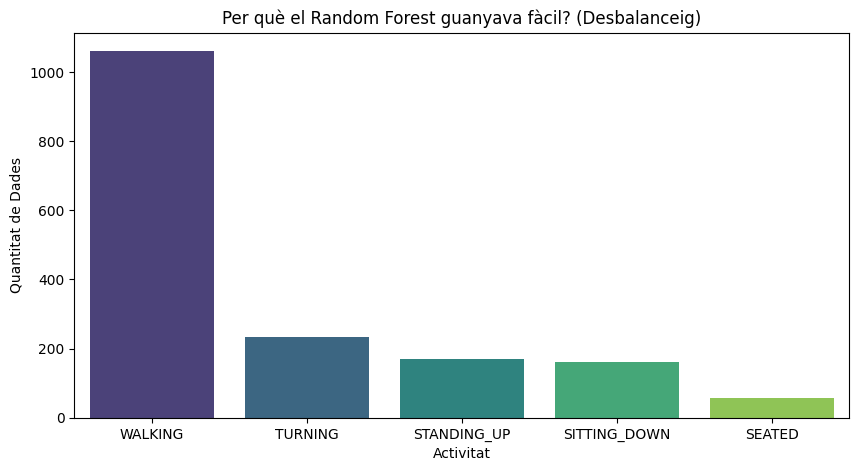

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------------------
# AUDITORIA DE CLASSES (QUÈ HI HA DINS DEL NOSTRE DATASET?)
# -----------------------------------------------------------------------------
def auditar_classes(y_dades):
    # Convertim el vector de números a noms per entendre-ho millor
    mapa_invers = {0: 'SEATED', 1: 'STANDING_UP', 2: 'WALKING', 3: 'TURNING', 4: 'SITTING_DOWN'}
    noms_y = [mapa_invers[i] for i in y_dades]

    # Comptem
    df_counts = pd.Series(noms_y).value_counts().reset_index()
    df_counts.columns = ['Activitat', 'Número de Finestres']

    # Calculem percentatge
    total = len(noms_y)
    df_counts['Percentatge'] = (df_counts['Número de Finestres'] / total) * 100

    print("\n📊 DISTRIBUCIÓ REAL DE LES DADES:")
    print(df_counts)

    # Gràfic
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_counts, x='Activitat', y='Número de Finestres', palette='viridis')
    plt.title("Per què el Random Forest guanyava fàcil? (Desbalanceig)")
    plt.ylabel("Quantitat de Dades")
    plt.show()

# EXECUCIÓ
# Utilitzem la 'y' que ja tenim carregada a la memòria
auditar_classes(y)

In [18]:
def auditar_realitat_crua_fila_a_fila(dataset_dict):
    print("--- 🕵️‍♂️ AUDITORIA REAL DE FILES (ROW-LEVEL) ---")

    # Comptador global de files per activitat
    comptador_files = {}

    for key, df in dataset_dict.items():
        if 'activity_id' in df.columns:
            # Comptem quantes vegades surt cada ID en aquest fitxer concret
            # Això compta les files reals, no fa mitjanes
            counts = df['activity_id'].value_counts()

            # Sumem al total global
            for act_id, count in counts.items():
                comptador_files[act_id] = comptador_files.get(act_id, 0) + count

    # --- MOSTREM RESULTATS ---
    mapa = {0: 'SEATED', 1: 'STANDING_UP', 2: 'WALKING', 3: 'TURNING', 4: 'SITTING_DOWN'}

    print(f"\n{'ACTIVITAT':<15} | {'FILES REALS (Mostres a 100Hz)':<30}")
    print("-" * 50)

    total_files = sum(comptador_files.values())

    for act_id in sorted(mapa.keys()):
        nom = mapa[act_id]
        num_rows = comptador_files.get(act_id, 0)
        pct = (num_rows / total_files) * 100 if total_files > 0 else 0

        # El pct hauria de quadrar amb el 63% de Walking que hem vist abans
        print(f"{nom:<15} | {num_rows:<10} ({pct:.1f}%)")

# EXECUCIÓ
auditar_realitat_crua_fila_a_fila(dataset_dict)

--- 🕵️‍♂️ AUDITORIA REAL DE FILES (ROW-LEVEL) ---

ACTIVITAT       | FILES REALS (Mostres a 100Hz) 
--------------------------------------------------
SEATED          | 32621      (12.6%)
STANDING_UP     | 27303      (10.5%)
WALKING         | 115069     (44.4%)
TURNING         | 52209      (20.2%)
SITTING_DOWN    | 31763      (12.3%)
